In [1]:
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'

In [10]:
# === Conexion Athena estilo Cruce + fallback awswrangler ===
import os
import re
import sys
from pathlib import Path

import boto3
import awswrangler as wr
import pandas as pd

EXPLICIT_CREDENTIALS_SH = Path(r"c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test/credentials.sh")


def _find_dir_with_athena_client(preferred_dir: Path | None = None) -> Path | None:
    cwd = Path.cwd().resolve()
    search_roots = []

    if preferred_dir is not None:
        search_roots.append(preferred_dir)

    search_roots.extend([cwd, *cwd.parents])

    home = Path.home()
    search_roots.extend([
        home / "OneDrive - Interbank" / "conexion_aws" / "athena_conection_test",
        Path("c:/Users/b46637/OneDrive - Interbank/conexion_aws/athena_conection_test"),
    ])

    visited = set()
    for root in search_roots:
        if root in visited:
            continue
        visited.add(root)

        if not root.exists():
            continue
        if (root / "athena_client.py").exists() and (root / "athena_config.json").exists():
            return root
    return None


def _load_credentials_from_sh(sh_path: Path) -> list[str]:
    if not sh_path.exists():
        return []

    loaded_keys: list[str] = []
    pattern = re.compile(r'^\s*export\s+([A-Za-z_][A-Za-z0-9_]*)=(.*)$')

    for line in sh_path.read_text(encoding="utf-8", errors="ignore").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        match = pattern.match(line)
        if not match:
            continue

        key, raw_val = match.groups()
        value = raw_val.strip().strip('"').strip("'")
        if key and value:
            os.environ[key] = value
            loaded_keys.append(key)

    return loaded_keys


def _build_session(aws_region: str) -> boto3.Session:
    aws_profile = os.getenv("AWS_PROFILE")
    if aws_profile:
        return boto3.Session(profile_name=aws_profile, region_name=aws_region)
    return boto3.Session(region_name=aws_region)


def _session_is_valid(sess: boto3.Session) -> tuple[bool, str | None]:
    try:
        sts = sess.client("sts")
        _ = sts.get_caller_identity()
        return True, None
    except Exception as exc:
        return False, str(exc)


ATHENA_MODE = "wrangler"
ATHENA_DATABASE = os.getenv("ATHENA_DATABASE", "disc_comercial")
ATHENA_WORKGROUP = os.getenv("ATHENA_WORKGROUP", "primary")
ATHENA_OUTPUT = os.getenv(
    "ATHENA_OUTPUT",
    "s3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/athena_results/"
 )
AWS_REGION = os.getenv("AWS_REGION", "us-east-1")

client = None

credentials_file = EXPLICIT_CREDENTIALS_SH if EXPLICIT_CREDENTIALS_SH.exists() else None
if credentials_file is None:
    print(f"⚠ No se encontró credentials.sh en ruta fija: {EXPLICIT_CREDENTIALS_SH}")

preferred_dir = credentials_file.parent if credentials_file is not None else None
athena_dir = _find_dir_with_athena_client(preferred_dir=preferred_dir)
loaded_cred_keys: list[str] = []

if credentials_file is not None:
    loaded_cred_keys = _load_credentials_from_sh(credentials_file)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {credentials_file}")
elif athena_dir is not None:
    fallback_sh = athena_dir / "credentials.sh"
    loaded_cred_keys = _load_credentials_from_sh(fallback_sh)
    if loaded_cred_keys:
        print(f"✓ Credenciales cargadas desde: {fallback_sh}")

try:
    session = _build_session(AWS_REGION)
except Exception:
    session = boto3.Session(region_name=AWS_REGION)

ok_session, session_error = _session_is_valid(session)
if not ok_session and session_error and "ExpiredToken" in session_error and loaded_cred_keys:
    print("⚠ Se detectó token expirado en credentials.sh. Reintentando con credenciales locales (perfil/default)...")
    for key in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_SESSION_TOKEN"]:
        os.environ.pop(key, None)
    session = _build_session(AWS_REGION)

if athena_dir is not None:
    if str(athena_dir) not in sys.path:
        sys.path.append(str(athena_dir))
    try:
        from athena_client import AthenaClient

        if credentials_file is None:
            credentials_file = athena_dir / "credentials.sh"

        client = AthenaClient(
            credentials_file=str(credentials_file),
            config_file=str(athena_dir / "athena_config.json"),
        )
        ATHENA_MODE = "athena_client"
        print(f"✓ AthenaClient cargado desde: {athena_dir}")
    except Exception as exc:
        print(f"⚠ No se pudo inicializar AthenaClient ({exc}). Se usará awswrangler.")
else:
    print("⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.")


def athena_query(query: str, database: str = ATHENA_DATABASE) -> pd.DataFrame:
    if ATHENA_MODE == "athena_client" and client is not None:
        return client.query(query)
    return wr.athena.read_sql_query(
        sql=query,
        database=database,
        ctas_approach=False,
        boto3_session=session,
        workgroup=ATHENA_WORKGROUP,
        s3_output=ATHENA_OUTPUT,
    )


def s3_read_csv(path: str, sep: str = "|", **kwargs) -> pd.DataFrame:
    return wr.s3.read_csv(path=path, sep=sep, boto3_session=session, **kwargs)


def test_aws_connection(sample_s3_path: str | None = None) -> None:
    sts = session.client("sts")
    ident = sts.get_caller_identity()
    print(f"✓ AWS Account: {ident.get('Account')} | ARN: {ident.get('Arn')}")

    if sample_s3_path:
        _ = wr.s3.read_csv(path=sample_s3_path, sep='|', boto3_session=session, nrows=1)
        print(f"✓ Lectura S3 OK: {sample_s3_path}")


print(f"Modo Athena activo: {ATHENA_MODE}")
print(f"DB: {ATHENA_DATABASE} | WG: {ATHENA_WORKGROUP}")
print(f"credentials.sh en uso: {credentials_file}")
print("Helper Athena: athena_query(query)")
print("Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')")
print("Diagnóstico opcional: test_aws_connection()")

✓ Credenciales cargadas desde: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
⚠ No se encontró athena_client.py + athena_config.json. Se usará awswrangler.
Modo Athena activo: wrangler
DB: disc_comercial | WG: primary
credentials.sh en uso: c:\Users\b46637\OneDrive - Interbank\conexion_aws\athena_conection_test\credentials.sh
Helper Athena: athena_query(query)
Helper S3 CSV: s3_read_csv('s3://bucket/prefix/file.txt', sep='|')
Diagnóstico opcional: test_aws_connection()


In [11]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from numpy import loadtxt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, roc_auc_score 
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from sklearn import linear_model
from sklearn.neural_network import MLPClassifier
import pylab as pl

from collections import Counter
from sklearn.datasets import make_classification

In [12]:
# Función para comprimir datos #######################################################
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))
    return df

In [13]:
import numpy as np

In [14]:
###Tabla_Deciles

def Tabla_Deciles(objective,probas,n=10):
    data={'Objective':objective}
    df_deciles=pd.DataFrame(data,columns=['Objective'])
    df_deciles['probas']=probas
    df_deciles['Rangos']=pd.qcut(df_deciles['probas'],n,duplicates='drop')
    cross_tab=pd.crosstab(df_deciles['Rangos'],df_deciles['Objective'],rownames=['Rangos'],colnames=['Objective'])
    a=0;b=1
    cross_tab['Efectividad']=(cross_tab[1]/cross_tab[[0,1]].sum(axis=1))
    cross_tab['%CumSum_{}'.format(a)]=cross_tab[a].cumsum()/cross_tab[a].sum()
    cross_tab['%CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]/cross_tab[b].sum()
    cross_tab['CumSum_{}'.format(a)]=cross_tab[a].cumsum()
    cross_tab['CumSum_{}'.format(b)]=cross_tab.loc[::-1,b].cumsum()[::-1]
    return cross_tab

# MODELOS

In [15]:
# from sagemaker.tuner import HyperparameterTuner  ← requiere sagemaker instalado
# El nombre del mejor job ya está hardcodeado en la celda de carga del modelo
nombre_exportado = 'hpo-plaft-pn-masivo-260701-1603-042-a270185f'
print(nombre_exportado)


hpo-plaft-pn-masivo-260701-1603-042-a270185f


In [16]:
!pip install xgboost --prefer-binary

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: C:\Program Files\Python314\python.exe -m pip install --upgrade pip


In [17]:
import boto3
import tarfile
import xgboost as xgb
import os

# Parámetros
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'
nombre_exportado = 'hpo-plaft-pn-masivo-260701-1603-042-a270185f'

# Descargar model.tar.gz desde S3
s3 = boto3.client('s3')

with open('model.tar.gz', 'wb') as f:
    s3.download_fileobj(
        bucket_name,
        f'{model_prefix}/MODEL/output/{nombre_exportado}/output/model.tar.gz',
        f
    )

# Extraer el archivo tar.gz
with tarfile.open('model.tar.gz', 'r:gz') as tar:
    tar.extractall(path='model')

# Cargar el modelo con XGBoost
model_path = os.path.join('model', 'xgboost-model')
model = xgb.Booster()
model.load_model(model_path)

# ¡Listo! Ya podés usar model.predict(...) con DMatrix

C:\Users\b46637\AppData\Local\Temp\ipykernel_39300\3505249116.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='model')


In [18]:
import pandas as pd

import pandas as pd

# ===============================================================
# 1. Parámetros de tu bucket y prefijo
# ===============================================================
bucket_name ='ibk-discovery-comercial-us-east-1-654654352211-data'
model_prefix = 'discovery/comercial/sanherna/PLAFT/PN/MASIVO/DATA_INFERENCIA_PILOTO'

# Ejemplo completo:
# bucket_name  = "sagemaker-us-east-1-123456789012"
# model_prefix = "risk-fraud-model/2025-12-05"

# ===============================================================
# 2. Rutas en S3
# ===============================================================
base_s3_path = f"s3://{bucket_name}/{model_prefix}/data_dev_model"

headers_path      = f"{base_s3_path}/headers_total.csv"
test_path         = f"{base_s3_path}/test_total_1.csv"
extras_test_path  = f"{base_s3_path}/extras_test_total.csv"

# ===============================================================
# 3. Cargar headers (orden y tipos)
# ===============================================================
headers = pd.read_csv(headers_path)
column_order = headers['variables'].tolist()

print(f"Se cargaron {len(column_order)} variables desde S3")
print("Primeras 10 variables:", column_order[:10])

# ===============================================================
# 4. Cargar train / val / test SIN header, pero CON nombres correctos
# ===============================================================
df_test  = pd.read_csv(test_path,  header=None, names=column_order)

print(f"\nShapes cargados desde S3:")
print(f"  Test  : {df_test.shape}")

# ===============================================================
# 5. Cargar extras (num_documento, mes_base, tipo_alerta_n2)
# ===============================================================
extras_test = pd.read_csv(extras_test_path)

# Pegamos las columnas de reporting al dataframe original

df_test = pd.concat([df_test.reset_index(drop=True), 
                     extras_test[['cod_mes', 'key_value' ,'cuc_num']]], axis=1)

# ===============================================================
# 6. Verificación final
# ===============================================================
print("\nListo! Todo cargado correctamente desde S3")
print(f"df_test ahora tiene {df_test.shape[1]} columnas")

# Ejemplo rápido de uso
display(df_test[['key_value', 'cuc_num' ,'cod_mes', 'target']].head())

Se cargaron 35 variables desde S3
Primeras 10 variables: ['target', 'concentracion_dia_max', 'n_canales_distintos', 'monto_max_soles', 'monto_debitos_soles', 'ratio_debito_credito', 'fe_ratio_salidas_entradas', 'n_trx_otros', 'monto_transferencias_soles', 'imp_trx_abonosefect_12m']

Shapes cargados desde S3:
  Test  : (6358050, 35)

Listo! Todo cargado correctamente desde S3
df_test ahora tiene 38 columnas


,key_value,cuc_num,cod_mes,target
0,D1FA89121636C81BCC5816FF4840032C37AD4EB4FB23CA...,7135023.0,202607.0,0.0
1,8F35110497919E288511F6E646BA67089C05E64437E67D...,13856667.0,202607.0,0.0
2,C5176BDC3F2EA33DB0EB40AFB8FC339F279ABC6792B9A0...,12869737.0,202607.0,0.0
3,80DBDC4322AC0CD37A723692205602AFD376EA5A9DD998...,19484792.0,202607.0,0.0
4,33E2E992D0FF6957EE2CEBB13CD6D45AA8C0B84D2B626E...,18830450.0,202607.0,0.0


In [10]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [11]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 !='0')]

In [19]:
df_test_1= df_test

In [20]:
# Guardar parquet en S3
#df_test_0426.to_parquet(
#    's3://ibk-discovery-comercial-us-east-1-654654352211-data/discovery/comercial/sanherna/PLAFT/PJ/MINORISTA/DATA_INFERENCIA_PILOTO/202604.parquet',
#    index=False
#)

In [21]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
df_test_3 = df_test_1.copy()
#test_data_0825_2= test_data_0825_1[(test_data_0825_1.tipo_alerta_n2 !='0')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cuc_num' ,'cod_mes']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_3.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [22]:
df_test_3['prob'] = model.predict(dtest)

In [23]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_test_3.groupby('cod_mes').apply(
    lambda x: gini(x['target'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202607.0   -0.017053
dtype: float64


C:\Users\b46637\AppData\Local\Temp\ipykernel_39300\29427415.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_test_3.groupby('cod_mes').apply(


In [24]:
gini_promedio = gini_por_mes.mean()

print(f"\nGini promedio de todos los meses: {gini_promedio:.4f}")



Gini promedio de todos los meses: -0.0171


In [25]:
#df_test_1 = df_test[df_test['cod_mes'].between(202508, 202604)].copy()

In [26]:
import xgboost as xgb
import pandas as pd

# Tu DataFrame de test
#df_test_2 = df_test_1.copy()
#df_test_3= df_test_2[(df_test_2.tipo_alerta_n2 =='AUTOMATICA')&(df_test_2.trx_riesgo_cliente !='A')]




# Variables a excluir (no estuvieron en el entrenamiento)
cols_excluir = ['key_value', 'cuc_num' ,'cod_mes']

# Seleccionamos solo las columnas usadas en entrenamiento
X_test = df_test_1.drop(columns=cols_excluir, errors='ignore')

# Asegurarnos de no tener la columna target si existiera
X_test = X_test.drop(columns=['target'], errors='ignore')

# Crear DMatrix para XGBoost con soporte para categóricas
dtest = xgb.DMatrix(X_test, enable_categorical=True)

In [27]:
predictions = model.predict(dtest)
y_test = df_test_1.target.to_frame()
y_test['prob'] = predictions
y_test_1=y_test['target'].values
y_score=y_test['prob'].values
y_test['Rangos']=pd.qcut(y_test['prob'],10,duplicates='drop')
Tabla_Deciles(y_test['target'],y_test['prob'],n=5)

Objective,0.0,1.0,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-0.000772, 0.0169]",1271714,25,0.000020,0.200020,1.000000,1271714,117
"(0.0169, 0.308]",1271447,34,0.000027,0.399998,0.786325,2543161,92
"(0.308, 0.704]",1390454,20,0.000014,0.618694,0.495726,3933615,58
"(0.704, 0.761]",2142117,14,0.000007,0.955614,0.324786,6075732,38
"(0.761, 0.998]",282201,24,0.000085,1.000000,0.205128,6357933,24


C:\Users\b46637\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo entrenado con 34 features
Muestra SHAP: 5,000 filas x 34 variables
  Positivos: 117 | Negativos: 4883

--- SHAP: Importancia absoluta (mean |SHAP|) ---


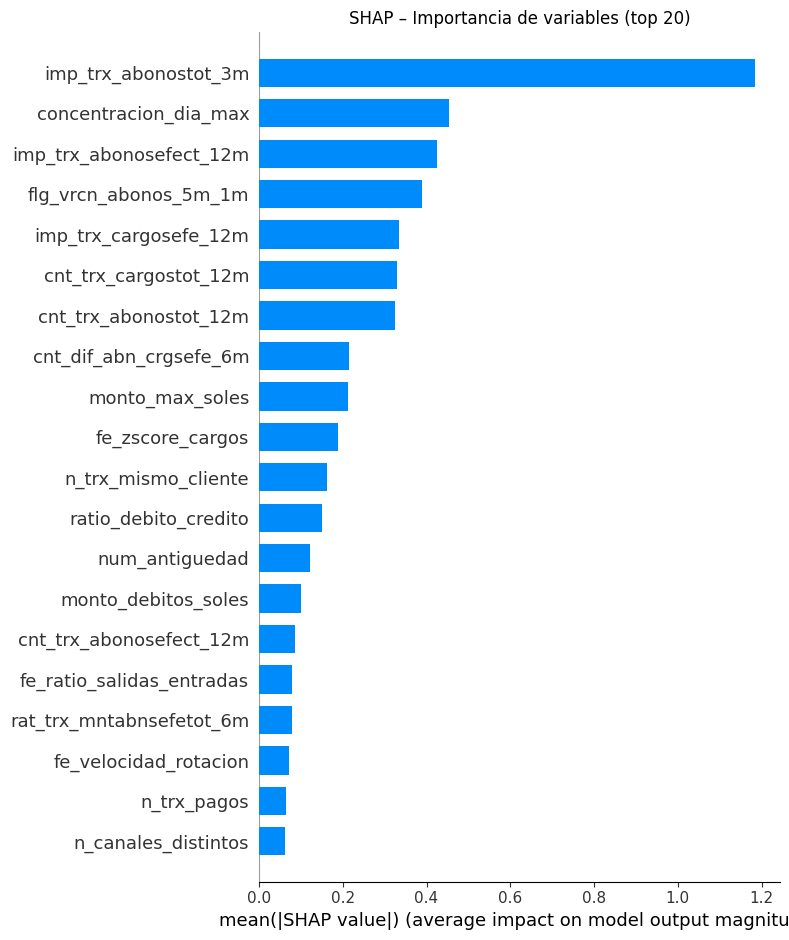


--- SHAP Beeswarm: dirección del efecto ---


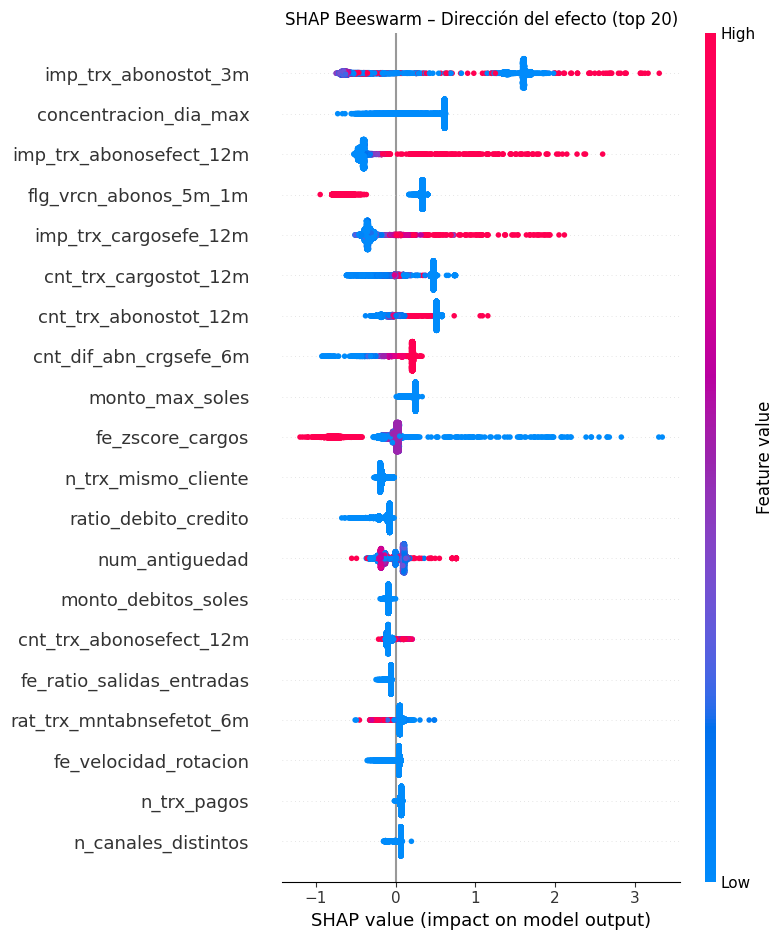


--- Tabla SHAP con dirección (top 20) ---


,variable,shap_importancia,shap_valor_alto,shap_valor_bajo,efecto
0,imp_trx_abonostot_3m,1.1847,-0.3561,1.5893,🟠 Valor bajo → AUMENTA riesgo
1,concentracion_dia_max,0.4538,nan,0.3961,🟠 Valor bajo → AUMENTA riesgo
2,imp_trx_abonosefect_12m,0.4242,-0.0210,-0.4213,⚪ Efecto mixto / débil
3,flg_vrcn_abonos_5m_1m,0.3904,-0.6490,0.3275,🟠 Valor bajo → AUMENTA riesgo
4,imp_trx_cargosefe_12m,0.3335,-0.1250,-0.3441,⚪ Efecto mixto / débil
5,cnt_trx_cargostot_12m,0.3289,-0.1254,0.4525,🟠 Valor bajo → AUMENTA riesgo
6,cnt_trx_abonostot_12m,0.3248,-0.0702,0.5158,🟠 Valor bajo → AUMENTA riesgo
7,cnt_dif_abn_crgsefe_6m,0.2145,0.2086,0.1387,🔴 Valor alto → AUMENTA riesgo
8,monto_max_soles,0.2119,nan,0.2119,🟠 Valor bajo → AUMENTA riesgo
9,fe_zscore_cargos,0.1895,-0.7658,0.0192,🟠 Valor bajo → AUMENTA riesgo


In [28]:

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# ================================================================
# SHAP Analysis – usa model.feature_names para evitar shape mismatch
# ================================================================

N_SAMPLE     = 5_000
RANDOM_STATE = 42

# Features exactas que el modelo espera
_model_features = model.feature_names
print(f"Modelo entrenado con {len(_model_features)} features")

# --- 0. Índices sin copiar el df ---
_mask_pos = (df_test_1['target'] == 1).to_numpy()
_mask_neg = (df_test_1['target'] == 0).to_numpy()
_all_idx  = np.arange(len(df_test_1))

_idx_pos = _all_idx[_mask_pos]
_idx_neg = _all_idx[_mask_neg]

n_pos = min(len(_idx_pos), max(50, int(N_SAMPLE * 0.10)))
n_neg = N_SAMPLE - n_pos

rng = np.random.default_rng(RANDOM_STATE)
_sampled_idx = np.concatenate([
    rng.choice(_idx_pos, size=n_pos, replace=False),
    rng.choice(_idx_neg, size=n_neg, replace=False),
])
rng.shuffle(_sampled_idx)

# --- 1. Construir X_shap con EXACTAMENTE las features del modelo ---
X_shap = pd.DataFrame(
    {col: df_test_1[col].to_numpy()[_sampled_idx] for col in _model_features}
).reset_index(drop=True)

d_shap = xgb.DMatrix(X_shap, enable_categorical=True)
print(f"Muestra SHAP: {d_shap.num_row():,} filas x {d_shap.num_col()} variables")
print(f"  Positivos: {n_pos} | Negativos: {n_neg}")

# --- 2. SHAP values ---
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(d_shap)
shap_df     = pd.DataFrame(shap_values, columns=X_shap.columns)

# --- 3. Bar plot (top 20) ---
print("\n--- SHAP: Importancia absoluta (mean |SHAP|) ---")
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=20, show=False)
plt.title("SHAP – Importancia de variables (top 20)")
plt.tight_layout()
plt.show()

# --- 4. Beeswarm (top 20) ---
print("\n--- SHAP Beeswarm: dirección del efecto ---")
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.title("SHAP Beeswarm – Dirección del efecto (top 20)")
plt.tight_layout()
plt.show()

# --- 5. Tabla resumen ---
resultados_shap = []
for col in X_shap.columns:
    mediana   = X_shap[col].median()
    mask_alto = X_shap[col] > mediana
    idx_col   = X_shap.columns.get_loc(col)

    shap_global = np.abs(shap_values[:, idx_col]).mean()
    shap_alto   = shap_df.loc[mask_alto,  col].mean()
    shap_bajo   = shap_df.loc[~mask_alto, col].mean()

    if shap_alto > 0.01:
        efecto = "🔴 Valor alto → AUMENTA riesgo"
    elif shap_bajo > 0.01:
        efecto = "🟠 Valor bajo → AUMENTA riesgo"
    else:
        efecto = "⚪ Efecto mixto / débil"

    resultados_shap.append({
        "variable":         col,
        "shap_importancia": shap_global,
        "shap_valor_alto":  shap_alto,
        "shap_valor_bajo":  shap_bajo,
        "efecto":           efecto,
    })

df_shap_resumen = (
    pd.DataFrame(resultados_shap)
    .sort_values("shap_importancia", ascending=False)
    .reset_index(drop=True)
)

print("\n--- Tabla SHAP con dirección (top 20) ---")
display(
    df_shap_resumen.head(20)
    .style.format({
        "shap_importancia": "{:.4f}",
        "shap_valor_alto":  "{:.4f}",
        "shap_valor_bajo":  "{:.4f}",
    })
    .background_gradient(subset=["shap_valor_alto"], cmap="RdYlGn", vmin=-0.3, vmax=0.3)
)


In [24]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')&(df_test.trx_riesgo_cliente !='A')]

In [25]:
#df_test_1= df_test[(df_test.tipo_alerta_n2 =='AUTOMATICA')]

Modelo entrenado con 34 features
Muestra 202508: 5,000 filas  (pos=130, neg=4870)
DMatrix SHAP: 5000 filas x 34 columnas

--- SHAP: Importancia absoluta (top 20) ---


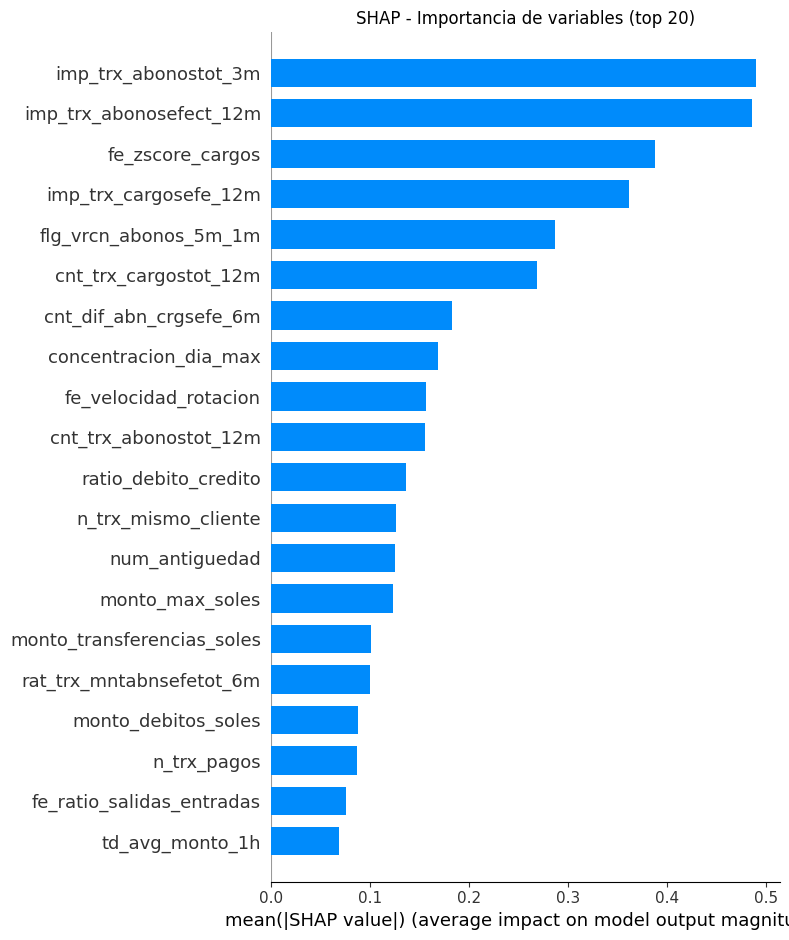


--- SHAP Beeswarm: dirección del efecto ---


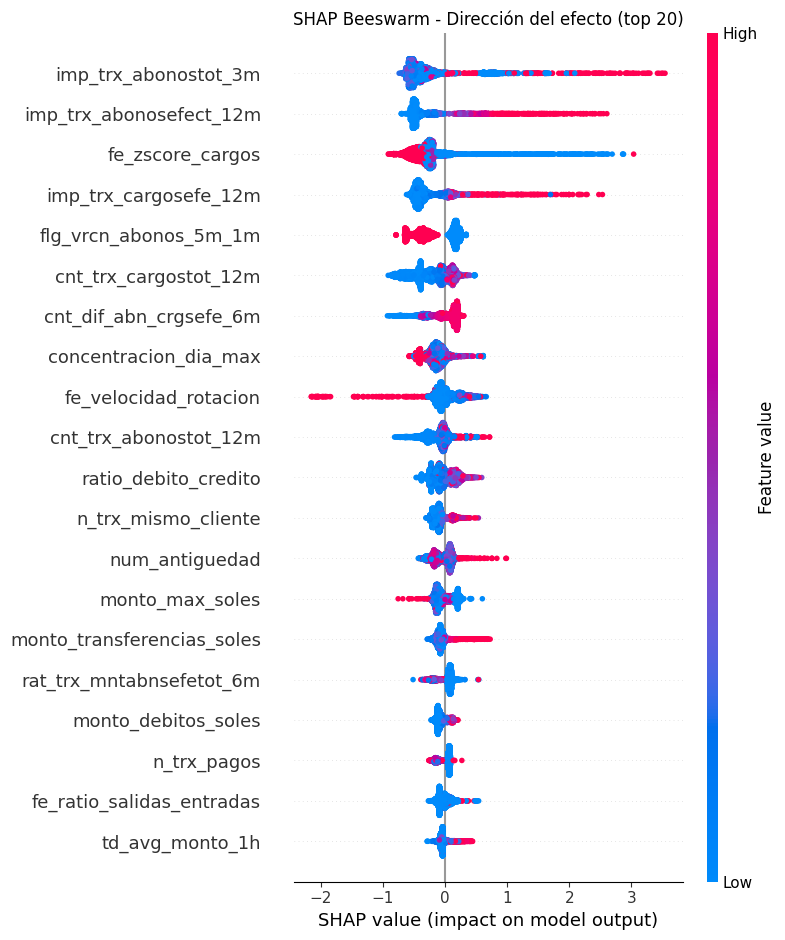


--- Tabla SHAP con dirección correcta (top 20) ---


,nombre_gerencial,shap_importancia,shap_si_valor_alto,shap_si_valor_bajo,efecto_real
0,Monto total de depósitos (últimos 3 meses),0.4895,-0.3311,-0.1865,⚪ Efecto mixto / débil
1,Monto total depositado en efectivo (12m),0.4861,0.0009,-0.4980,⚪ Efecto mixto / débil
2,Comportamiento atípico de egresos,0.3874,-0.4560,-0.0599,⚪ Efecto mixto / débil
3,Monto anual egresos en efectivo,0.3616,-0.0701,-0.4264,⚪ Efecto mixto / débil
4,Incremento reciente de depósitos,0.2868,nan,-0.1242,⚪ Efecto mixto / débil
5,Número de egresos (12m),0.2689,0.0256,-0.4321,🔴 Valor alto → AUMENTA riesgo
6,Dif. operaciones en efectivo (6m),0.1827,0.1616,-0.0145,🔴 Valor alto → AUMENTA riesgo
7,Concentración máx. transacciones por día,0.1688,-0.1774,-0.1134,⚪ Efecto mixto / débil
8,Intensidad de uso de fondos,0.1567,0.0942,-0.0883,🔴 Valor alto → AUMENTA riesgo
9,Número de depósitos totales (12m),0.1555,-0.0039,-0.2102,⚪ Efecto mixto / débil


In [26]:

import shap
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt

# ================================================================
# SHAP mes 202508 – features exactas del modelo
# ================================================================
N_SAMPLE     = 5_000
RANDOM_STATE = 42

_model_features = model.feature_names
print(f"Modelo entrenado con {len(_model_features)} features")

_all_idx = np.arange(len(df_test_1))
_mes_arr = df_test_1['cod_mes'].to_numpy()
_tgt_arr = df_test_1['target'].to_numpy()

# cod_mes puede ser float (202508.0) → comparar con float
_idx_pos = _all_idx[(_mes_arr == 202508) | (_mes_arr == 202508.0)]
_idx_neg_mes = _all_idx[(_mes_arr == 202508) | (_mes_arr == 202508.0)]
_idx_pos = _all_idx[((_mes_arr == 202508) | (_mes_arr == 202508.0)) & (_tgt_arr == 1)]
_idx_neg = _all_idx[((_mes_arr == 202508) | (_mes_arr == 202508.0)) & (_tgt_arr == 0)]

n_pos = min(len(_idx_pos), max(50, int(N_SAMPLE * 0.10)))
n_neg = min(len(_idx_neg), N_SAMPLE - n_pos)

rng = np.random.default_rng(RANDOM_STATE)
_sampled_idx = np.concatenate([
    rng.choice(_idx_pos, size=n_pos, replace=False),
    rng.choice(_idx_neg, size=n_neg, replace=False),
])
rng.shuffle(_sampled_idx)

print(f"Muestra 202508: {len(_sampled_idx):,} filas  (pos={n_pos}, neg={n_neg})")

# Features exactas del modelo
X_ref = pd.DataFrame(
    {col: df_test_1[col].to_numpy()[_sampled_idx] for col in _model_features}
).reset_index(drop=True)

dref = xgb.DMatrix(X_ref, enable_categorical=True)
print(f"DMatrix SHAP: {dref.num_row()} filas x {dref.num_col()} columnas")

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(dref)

# ================================================================
# Nombres gerenciales
# ================================================================
nombres_gerenciales_shap = {
    'imp_trx_abonosefect_12m':     'Monto total depositado en efectivo (12m)',
    'imp_trx_cargostot_1m':        'Monto total de egresos último mes',
    'cnt_trx_cargostot_12m':       'Número de egresos (12m)',
    'fe_zscore_cargos':            'Comportamiento atípico de egresos',
    'flg_vrcn_abonos_5m_1m':       'Incremento reciente de depósitos',
    'imp_trx_cargosefe_12m':       'Monto anual egresos en efectivo',
    'concentracion_dia_max':       'Concentración máx. transacciones por día',
    'fe_velocidad_rotacion':       'Intensidad de uso de fondos',
    'mto_dif_abn_crgsefe_6m':      'Dif. montos depósitos vs egresos efectivo (6m)',
    'ratio_debito_credito':        'Ratio egresos vs depósitos',
    'cnt_dif_abn_crgsefe_6m':      'Dif. operaciones en efectivo (6m)',
    'rat_trx_mntabnsefetot_6m':    'Proporción depósitos en efectivo (6m)',
    'monto_transferencias_soles':  'Monto transferencias en soles',
    'cnt_trx_abonostot_12m':       'Número de depósitos totales (12m)',
    'td_avg_monto_1h':             'Monto promedio en 1 hora (TD)',
    'flg_activo':                  'Cliente con productos activos',
    'num_antiguedad':              'Antigüedad del cliente',
    'n_trx_mismo_cliente':         'Transferencias entre cuentas propias',
    'monto_debitos_soles':         'Monto total egresos en soles',
    'monto_total_dolares':         'Monto total en dólares',
    'fe_ratio_salidas_entradas':   'Ratio salidas vs entradas',
    'monto_max_soles':             'Monto máximo de transacción',
    'cnt_trx_abonosefect_12m':     'Número depósitos en efectivo (12m)',
    'n_trx_pagos':                 'Número de pagos',
    'td_monto_total':              'Monto total tarjeta débito (mes)',
    'n_canales_distintos':         'Diversidad de canales',
    'monto_efectivo_soles':        'Monto total en efectivo',
    'fe_ratio_efectivo_vs_total':  'Proporción efectivo sobre total',
    'td_gap_promedio':             'Frecuencia de uso TD',
    'monto_promedio_dolares':      'Monto promedio en dólares',
    'n_trx_efectivo':              'Número de transacciones en efectivo',
    'n_trx_app':                   'Transacciones por APP',
    'tc_total_monto_mes':          'Monto total tarjeta crédito (mes)',
    'n_trx_otros':                 'Número de transacciones diversas',
    'imp_trx_abonostot_3m':        'Monto total de depósitos (últimos 3 meses)',
}

print("\n--- SHAP: Importancia absoluta (top 20) ---")
shap.summary_plot(shap_values, X_ref, plot_type="bar", max_display=20, show=False)
plt.title("SHAP - Importancia de variables (top 20)")
plt.tight_layout()
plt.show()

print("\n--- SHAP Beeswarm: dirección del efecto ---")
shap.summary_plot(shap_values, X_ref, max_display=20, show=False)
plt.title("SHAP Beeswarm - Dirección del efecto (top 20)")
plt.tight_layout()
plt.show()

shap_df_full = pd.DataFrame(shap_values, columns=X_ref.columns)
resultados = []
for col in X_ref.columns:
    mediana   = X_ref[col].median()
    mask_alto = X_ref[col] > mediana
    idx_col   = X_ref.columns.get_loc(col)

    shap_global = np.abs(shap_values[:, idx_col]).mean()
    shap_alto   = shap_df_full.loc[mask_alto,  col].mean()
    shap_bajo   = shap_df_full.loc[~mask_alto, col].mean()

    efecto = ('🔴 Valor alto → AUMENTA riesgo' if shap_alto > 0.01
              else '🟠 Valor bajo → AUMENTA riesgo' if shap_bajo > 0.01
              else '⚪ Efecto mixto / débil')

    resultados.append({
        'variable_original':  col,
        'shap_importancia':   shap_global,
        'shap_si_valor_alto': shap_alto,
        'shap_si_valor_bajo': shap_bajo,
        'efecto_real':        efecto,
    })

df_shap = (
    pd.DataFrame(resultados)
    .sort_values('shap_importancia', ascending=False)
    .reset_index(drop=True)
)
df_shap['nombre_gerencial'] = (
    df_shap['variable_original'].map(nombres_gerenciales_shap)
    .fillna(df_shap['variable_original'])
)

print("\n--- Tabla SHAP con dirección correcta (top 20) ---")
display(
    df_shap[['nombre_gerencial', 'shap_importancia', 'shap_si_valor_alto', 'shap_si_valor_bajo', 'efecto_real']]
    .head(20)
    .style.format({
        'shap_importancia':   '{:.4f}',
        'shap_si_valor_alto': '{:.4f}',
        'shap_si_valor_bajo': '{:.4f}',
    })
    .background_gradient(subset=['shap_si_valor_alto'], cmap='RdYlGn', vmin=-0.3, vmax=0.3)
)


X_ref2 shape: (5000, 34)  (modelo espera 34 features)


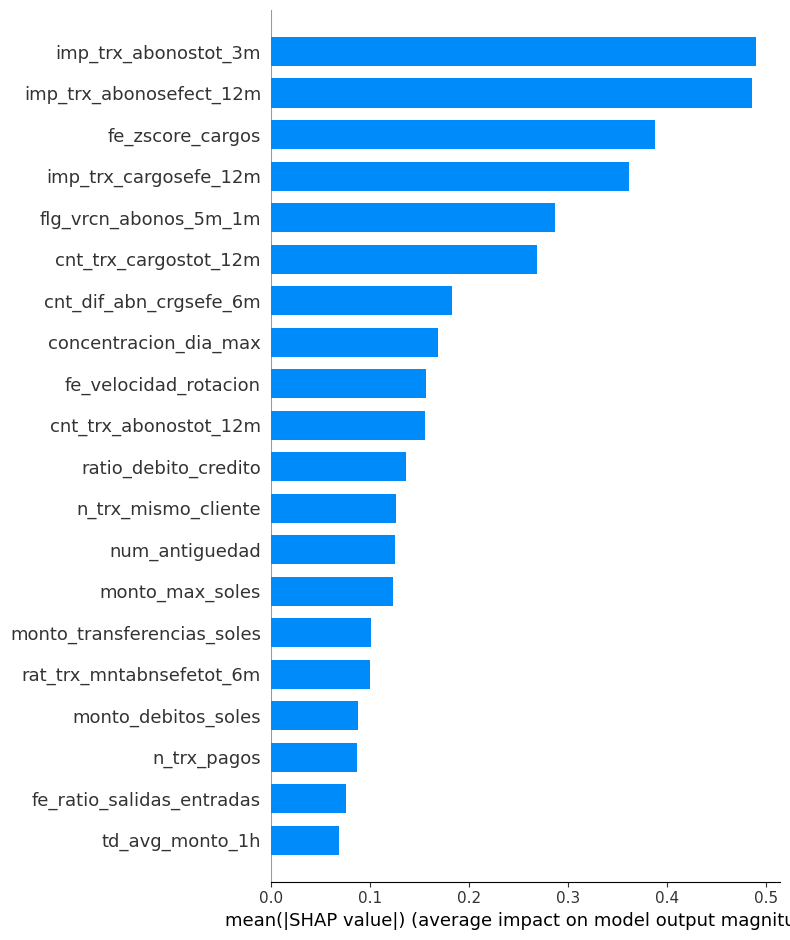

In [27]:

import shap
import pandas as pd
import numpy as np
import xgboost as xgb

# ================================================================
# SHAP summary bar – mes 202508, features exactas del modelo
# ================================================================
N_SAMPLE     = 5_000
RANDOM_STATE = 42

_model_features = model.feature_names

_all_idx2 = np.arange(len(df_test_1))
_mes_arr2 = df_test_1['cod_mes'].to_numpy()
_tgt_arr2 = df_test_1['target'].to_numpy()

_idx_pos2 = _all_idx2[((_mes_arr2 == 202508) | (_mes_arr2 == 202508.0)) & (_tgt_arr2 == 1)]
_idx_neg2 = _all_idx2[((_mes_arr2 == 202508) | (_mes_arr2 == 202508.0)) & (_tgt_arr2 == 0)]
n_pos2 = min(len(_idx_pos2), max(50, int(N_SAMPLE * 0.10)))
n_neg2 = min(len(_idx_neg2), N_SAMPLE - n_pos2)

rng2 = np.random.default_rng(RANDOM_STATE)
_sampled_idx2 = np.concatenate([
    rng2.choice(_idx_pos2, size=n_pos2, replace=False),
    rng2.choice(_idx_neg2, size=n_neg2, replace=False),
])
rng2.shuffle(_sampled_idx2)

# Features exactas del modelo
X_ref2 = pd.DataFrame(
    {col: df_test_1[col].to_numpy()[_sampled_idx2] for col in _model_features}
).reset_index(drop=True)

print(f"X_ref2 shape: {X_ref2.shape}  (modelo espera {len(_model_features)} features)")

explainer2   = shap.TreeExplainer(model)
shap_values2 = explainer2.shap_values(xgb.DMatrix(X_ref2, enable_categorical=True))

# Exponer para la celda siguiente
shap_values  = shap_values2
X_ref_global = X_ref2

shap.summary_plot(shap_values2, X_ref2, plot_type="bar", max_display=20)


In [28]:

# Usa las variables de la celda anterior (shap_values2 / X_ref_global)
variable_names = X_ref_global.columns

# Magnitud promedio de los SHAP values por variable
average_shap_values = np.abs(shap_values2).mean(axis=0)

# Lista de tuplas (variable, importancia_abs, shap_promedio)
variable_importance = [
    (name, imp, shap_mean)
    for name, imp, shap_mean in zip(
        variable_names,
        average_shap_values,
        shap_values2.mean(axis=0)
    )
]

# Orden descendente por importancia absoluta
variable_importance.sort(key=lambda x: x[1], reverse=True)
variables_mas_importantes = [(v[0], v[1], v[2]) for v in variable_importance]


In [29]:
import csv

# Nombre del archivo CSV de salida
output_csv = 'importancia_variables.csv'

# Escribe los datos en el archivo CSV
with open(output_csv, 'w', newline='') as csvfile:
    
    # Define el escritor CSV
    csv_writer = csv.writer(csvfile)
    
    # Escribe el encabezado
    csv_writer.writerow(['Variable', 'Importancia', 'Valor Absoluto SHAP'])
    
    # Escribe los datos de cada variable
    for variable in variables_mas_importantes:
        csv_writer.writerow([variable[0], variable[1], variable[2]])


In [30]:
variables_mas_importantes

[('imp_trx_abonostot_3m', np.float32(0.4894852), np.float32(-0.25877407)),
 ('imp_trx_abonosefect_12m', np.float32(0.48612458), np.float32(-0.292833)),
 ('fe_zscore_cargos', np.float32(0.38739598), np.float32(-0.24814191)),
 ('imp_trx_cargosefe_12m', np.float32(0.36163622), np.float32(-0.24849917)),
 ('flg_vrcn_abonos_5m_1m', np.float32(0.28683785), np.float32(-0.124244004)),
 ('cnt_trx_cargostot_12m', np.float32(0.26885265), np.float32(-0.20388737)),
 ('cnt_dif_abn_crgsefe_6m', np.float32(0.18272398), np.float32(0.010413499)),
 ('concentracion_dia_max', np.float32(0.16876453), np.float32(-0.14512095)),
 ('fe_velocidad_rotacion', np.float32(0.15668726), np.float32(0.0029607208)),
 ('cnt_trx_abonostot_12m', np.float32(0.1554598), np.float32(-0.107617564)),
 ('ratio_debito_credito', np.float32(0.13684975), np.float32(-0.0127345035)),
 ('n_trx_mismo_cliente', np.float32(0.12650959), np.float32(-0.08548961)),
 ('num_antiguedad', np.float32(0.12520042), np.float32(-0.041862145)),
 ('monto_m

In [31]:
%%time
query = """

WITH pd AS (
    SELECT DISTINCT
        -- Identificadores
        a.key_value as num_documento,
        a.cod_cli as codunico,
        date_format(
            date_parse(CAST(a.cod_mes AS varchar), '%Y%m') + interval '1' month,
            '%Y%m'
        ) AS codmes_lag1,
        CAST(a.cod_mes AS INTEGER) AS codmes

    

    FROM e_perm_aws.t_agg_alertas_plaft a
    WHERE a.cod_mes between '202508' AND '202607'
      AND a.desc_subsegmento  IN ('Masivo', 'Masivo Dependiente', 'Masivo Independiente')
),

target AS (
    SELECT 
        codunico,
        periodo_alerta,
        tipo_alerta_n2,
        trx_riesgo_cliente,
        MAX(calificacion_monitoreo) AS flg_alerta
    FROM e_perm_aws.t_alertas_plaft
    GROUP BY codunico, periodo_alerta, tipo_alerta_n2,trx_riesgo_cliente
)

SELECT 
    a.*,
    b.tipo_alerta_n2,
    b.trx_riesgo_cliente,
    CASE 
        WHEN b.flg_alerta = '1' THEN 1 
        ELSE 0 
    END AS target_m
FROM pd a
LEFT JOIN target b
    ON a.codunico = b.codunico
 AND cast(a.codmes as varchar) = b.periodo_alerta
where  b.tipo_alerta_n2 is not null

;"""
df_dataset = athena_query(query, database='disc_comercial')
df_dataset.head()

CPU times: total: 4.77 s
Wall time: 21.1 s


,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,014BD0650A7C1078EB92BAA028D282C943E38EAE5C8E43...,0017674966,202604,202603,SEMI AUTOMATICA,M,0
1,5F7CEFBDAA1C6C12B113F816117CADED8B403282E7D5C2...,0019938665,202512,202511,AUTOMATICA,M,1
2,9731DC10E34BAE0E5E66A5D8CEA3821F0550F7A63F686A...,0013822560,202509,202508,MANUAL,A,0
3,F20D425326126F212EA538CCAFE1E939D28B9EF6EF6F11...,0019217069,202510,202509,AUTOMATICA,A,1
4,50DBDDCBD1FEA93A483271BBAAACEA44581E2027129244...,0013140015,202605,202604,AUTOMATICA,M,0


In [32]:
df_dataset.codmes.value_counts()


codmes
202602    1054
202510     920
202605     883
202603     843
202604     741
202508     613
202509     553
202601     515
202511     476
202607     393
202512     342
202606     322
Name: count, dtype: Int64

In [33]:
df_test_3.head()

,target,concentracion_dia_max,n_canales_distintos,monto_max_soles,monto_debitos_soles,ratio_debito_credito,fe_ratio_salidas_entradas,n_trx_otros,monto_transferencias_soles,imp_trx_abonosefect_12m,...,monto_total_dolares,monto_promedio_dolares,mto_dif_abn_crgsefe_6m,n_trx_pagos,tc_total_monto_mes,flg_activo,cod_mes,key_value,cuc_num,prob
0,0.0,0.666667,3.0,200.00,199.60,2.000000,0.997950,0.0,201.60,0.0,...,0.0,0.0,-3094.6,0.0,0.00,0.0,202508.0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,0.012573
1,0.0,0.666667,3.0,1642.58,1642.63,2.000000,1.026637,2.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.00,1.0,202508.0,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,0.010481
2,0.0,0.134615,4.0,1369.62,4117.00,1.476190,0.838078,18.0,2829.00,0.0,...,0.0,0.0,-4810.0,4.0,0.00,1.0,202508.0,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,0.007718
3,0.0,0.108108,2.0,321.00,987.70,1.740741,1.034230,9.0,1379.70,720.0,...,0.0,0.0,-50.0,1.0,0.00,0.0,202508.0,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,0.009579
4,0.0,0.187500,4.0,12709.00,14168.20,1.000000,1.014612,7.0,25415.15,16490.0,...,0.0,0.0,-5870.0,6.0,26327.79,1.0,202508.0,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,0.119544


In [34]:
#df_final= df_test_3[['key_value', 'cuc_num', 'prob', 'codmes', 'num_documento', 'codunico']]

In [35]:
df_final= df_test_3[['key_value', 'cuc_num', 'prob', 'cod_mes']]

In [36]:
df_final.head()

,key_value,cuc_num,prob,cod_mes
0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,0.012573,202508.0
1,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,0.010481,202508.0
2,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,0.007718,202508.0
3,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,0.009579,202508.0
4,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,0.119544,202508.0


In [37]:
df_dataset.head()

,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,014BD0650A7C1078EB92BAA028D282C943E38EAE5C8E43...,0017674966,202604,202603,SEMI AUTOMATICA,M,0
1,5F7CEFBDAA1C6C12B113F816117CADED8B403282E7D5C2...,0019938665,202512,202511,AUTOMATICA,M,1
2,9731DC10E34BAE0E5E66A5D8CEA3821F0550F7A63F686A...,0013822560,202509,202508,MANUAL,A,0
3,F20D425326126F212EA538CCAFE1E939D28B9EF6EF6F11...,0019217069,202510,202509,AUTOMATICA,A,1
4,50DBDDCBD1FEA93A483271BBAAACEA44581E2027129244...,0013140015,202605,202604,AUTOMATICA,M,0


In [38]:
# Copias para no tocar los originales
df_final_m = df_final.copy()
df_dataset_m = df_dataset.copy()

# Normalizar claves
df_final_m["cuc_num"] = df_final_m["cuc_num"].astype(float).astype("Int64").astype(str)
df_final_m["cod_mes"] = df_final_m["cod_mes"].astype(float).astype("Int64").astype(str)

df_dataset_m["codunico"] = df_dataset_m["codunico"].astype("Int64").astype(str)
df_dataset_m["codmes"] = df_dataset_m["codmes"].astype("Int64").astype(str)

# Merge
df_merge = df_final_m.merge(
    df_dataset_m,
    how="inner",
    left_on=["cuc_num", "cod_mes"],
    right_on=["codunico", "codmes"]
)

print(df_merge.shape)
df_merge.head()

(4002, 11)


,key_value,cuc_num,prob,cod_mes,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,66F048EAC9D09040B93AB99DAC48BAD366BE348E8AF231...,15562692,0.421150,202508,66F048EAC9D09040B93AB99DAC48BAD366BE348E8AF231...,15562692,202509,202508,SEMI AUTOMATICA,A,1
1,5027F4F72EA5B4C455F511F1DC2D0F5D45831B3A4F3E20...,15538083,0.977331,202508,5027F4F72EA5B4C455F511F1DC2D0F5D45831B3A4F3E20...,15538083,202509,202508,AUTOMATICA,M,0
2,5B7914E3FFD850A1BE039BC92D2B1D04977D7F851515D6...,13353580,0.979677,202508,5B7914E3FFD850A1BE039BC92D2B1D04977D7F851515D6...,13353580,202509,202508,AUTOMATICA,A,1
3,5704D4082297C940650EA616D6CAA9B76325606F43DE1D...,17531638,0.759373,202508,5704D4082297C940650EA616D6CAA9B76325606F43DE1D...,17531638,202509,202508,MANUAL,B,1
4,CB2B0A40C65E1E9718B214C16BA4BDE9AB950415F1C910...,9669926,0.781205,202508,CB2B0A40C65E1E9718B214C16BA4BDE9AB950415F1C910...,9669926,202509,202508,AUTOMATICA,M,0


In [39]:
df_5 = df_merge[(df_merge.tipo_alerta_n2=='AUTOMATICA')]

In [40]:
import pandas as pd
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------
# Función para calcular Gini
# ---------------------------------------------------
def gini(actual, pred):
    auc = roc_auc_score(actual, pred)
    return 2*auc - 1

# ---------------------------------------------------
# Calcular Gini por mes usando 'codmes' y 'target_m'
# ---------------------------------------------------
gini_por_mes = df_5.groupby('cod_mes').apply(
    lambda x: gini(x['target_m'], x['prob'])
)

# Mostrar resultados
print("Gini por mes:")
print(gini_por_mes)


Gini por mes:
cod_mes
202508    0.355209
202510    0.638431
202511    0.369292
202602    0.370177
202604    0.242641
202605    0.339045
202606    0.570806
202607         NaN
dtype: float64


C:\Users\b46637\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\b46637\AppData\Local\Temp\ipykernel_59724\2626577288.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gini_por_mes = df_5.groupby('cod_mes').apply(


In [42]:
meses = [
    202508, 202510, 202511, 
    202601, 202602, 202603, 202605,202606   , 202607
]

tablas_quintiles = {}

# Normalizo mes
#df_merge["codmes_final"] = df_merge["codmes_final"].astype(str)

for mes in meses:
    mes_str = str(mes)

    test_data = df_5[
        df_5["cod_mes"] == mes_str
    ].copy()

    if test_data.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    if "target_m" not in test_data.columns:
        raise ValueError("No existe la columna target en df_4")

    if "prob" not in test_data.columns:
        raise ValueError("No existe la columna prob en df_4")

    tablas_quintiles[mes_str] = Tabla_Deciles(
        test_data["target_m"],
        test_data["prob"],
        n=5
    )

    print(f"✅ Mes {mes_str}: {len(test_data):,} registros")


✅ Mes 202508: 215 registros
✅ Mes 202510: 334 registros
✅ Mes 202511: 251 registros
⚠️ Sin datos para mes 202601
✅ Mes 202602: 415 registros
⚠️ Sin datos para mes 202603
✅ Mes 202605: 283 registros
✅ Mes 202606: 111 registros


KeyError: 1

In [43]:
tablas_quintiles['202508']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00258, 0.222]",41,2,0.046512,0.220430,1.000000,41,29
"(0.222, 0.631]",40,3,0.069767,0.435484,0.931034,81,27
"(0.631, 0.855]",37,6,0.139535,0.634409,0.827586,118,24
"(0.855, 0.954]",35,8,0.186047,0.822581,0.620690,153,18
"(0.954, 0.992]",33,10,0.232558,1.000000,0.344828,186,10


In [44]:
tablas_quintiles['202510']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.00038999999999999994, 0.44]",67,0,0.000000,0.223333,1.000000,67,34
"(0.44, 0.763]",64,3,0.044776,0.436667,1.000000,131,34
"(0.763, 0.907]",61,5,0.075758,0.640000,0.911765,192,31
"(0.907, 0.961]",63,4,0.059701,0.850000,0.764706,255,26
"(0.961, 0.99]",45,22,0.328358,1.000000,0.647059,300,22


In [45]:
tablas_quintiles['202602']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(0.0009599999999999999, 0.458]",75,8,0.096386,0.240385,1.000000,75,103
"(0.458, 0.785]",73,10,0.120482,0.474359,0.922330,148,95
"(0.785, 0.902]",62,21,0.253012,0.673077,0.825243,210,85
"(0.902, 0.961]",49,34,0.409639,0.830128,0.621359,259,64
"(0.961, 0.994]",53,30,0.361446,1.000000,0.291262,312,30


In [46]:
tablas_quintiles['202605']

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1
Rangos,,,,,,,
"(-3.0999999999999995e-05, 0.274]",55,2,0.035088,0.227273,1.000000,55,41
"(0.274, 0.718]",49,7,0.125000,0.429752,0.951220,104,39
"(0.718, 0.876]",51,6,0.105263,0.640496,0.780488,155,32
"(0.876, 0.959]",43,13,0.232143,0.818182,0.634146,198,26
"(0.959, 0.995]",44,13,0.228070,1.000000,0.317073,242,13


In [47]:
df_quintiles = pd.concat(
    [
        tabla.assign(mes=mes)
        for mes, tabla in tablas_quintiles.items()
    ],
    ignore_index=True
)

display(df_quintiles.head())

Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1,mes
0,41,2,0.046512,0.220430,1.000000,41,29,202508
1,40,3,0.069767,0.435484,0.931034,81,27,202508
2,37,6,0.139535,0.634409,0.827586,118,24,202508
3,35,8,0.186047,0.822581,0.620690,153,18,202508
4,33,10,0.232558,1.000000,0.344828,186,10,202508


In [48]:
df_quintiles = pd.concat(
    [
        tabla.reset_index(drop=True).assign(
            mes=str(mes),
            Quintil=range(len(tabla), 0, -1)  # P1 = mayor score (mayor riesgo)
        )
        for mes, tabla in tablas_quintiles.items()
    ],
    ignore_index=True
)

display(df_quintiles)


Objective,0,1,Efectividad,%CumSum_0,%CumSum_1,CumSum_0,CumSum_1,mes,Quintil
0,41,2,0.046512,0.220430,1.000000,41,29,202508,5
1,40,3,0.069767,0.435484,0.931034,81,27,202508,4
2,37,6,0.139535,0.634409,0.827586,118,24,202508,3
3,35,8,0.186047,0.822581,0.620690,153,18,202508,2
4,33,10,0.232558,1.000000,0.344828,186,10,202508,1
5,67,0,0.000000,0.223333,1.000000,67,34,202510,5
6,64,3,0.044776,0.436667,1.000000,131,34,202510,4
7,61,5,0.075758,0.640000,0.911765,192,31,202510,3
8,63,4,0.059701,0.850000,0.764706,255,26,202510,2
9,45,22,0.328358,1.000000,0.647059,300,22,202510,1


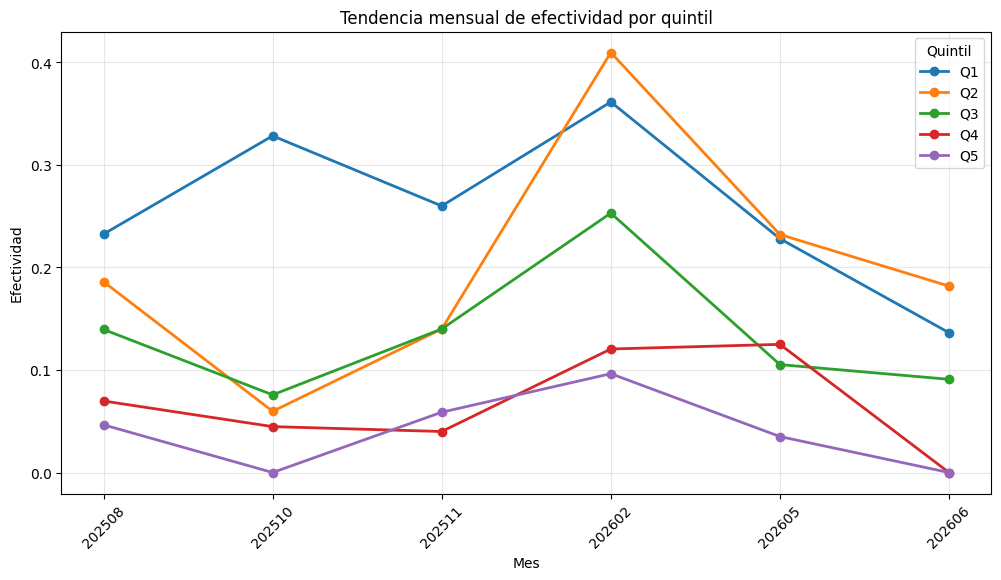

In [49]:
import matplotlib.pyplot as plt

pivot = df_quintiles.pivot_table(
    index="mes",
    columns="Quintil",
    values="Efectividad"
)

plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        linewidth=2,
        label=f"Q{col}"
    )

plt.title("Tendencia mensual de efectividad por quintil")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.legend(title="Quintil")
plt.xticks(rotation=45)
plt.show()

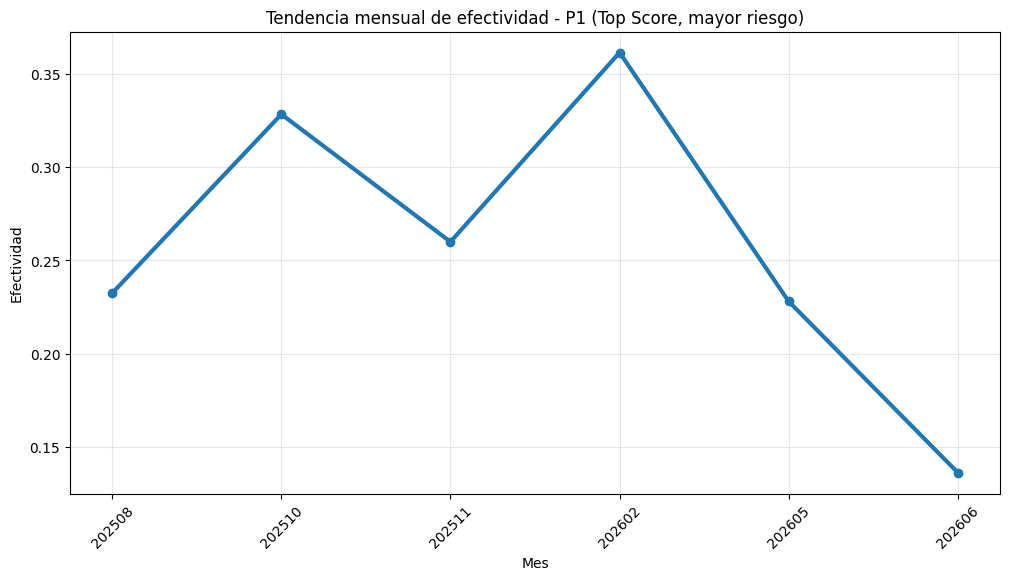

In [50]:
q_top = df_quintiles[df_quintiles["Quintil"] == 1].copy()  # P1 = mayor score

plt.figure(figsize=(12,6))

plt.plot(
    q_top["mes"],
    q_top["Efectividad"],
    marker="o",
    linewidth=3
)

plt.title("Tendencia mensual de efectividad - P1 (Top Score, mayor riesgo)")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


In [51]:
# Meses a excluir
meses_excluir = ["202509", "202512", "202601", "202603", "202604"]

# Dataset para análisis
df_analisis = df_5[
    ~df_5["cod_mes"].astype(str).isin(meses_excluir)
].copy()


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

# ================================
# 1. Mes base para cortes
# ================================
mes_base = "202508"

df_analisis["cod_mes"] = df_analisis["cod_mes"].astype(str)
df_analisis["prob"] = pd.to_numeric(df_analisis["prob"], errors="coerce")
df_analisis["target_m"] = pd.to_numeric(df_analisis["target_m"], errors="coerce")

base = df_analisis[df_analisis["cod_mes"] == mes_base].copy()

# Cortes fijos según 202508
cuts = base["prob"].quantile([0, 0.2, 0.4, 0.6, 0.8, 1]).values

# Evitar problemas si hay cortes repetidos
cuts[0] = -float("inf")
cuts[-1] = float("inf")

print("Cortes base 202508:")
print(cuts)

Cortes base 202508:
[      -inf 0.22177999 0.63117152 0.85452255 0.95391023        inf]


In [53]:

# ================================
# 2. Aplicar cortes fijos a todos los meses
# ================================
df_5["quintil_202508"] = pd.cut(
    df_5["prob"],
    bins=cuts,
    labels=[5, 4, 3, 2, 1],   # P1 = mayor score (mayor riesgo)
    include_lowest=True
)

# P1 = mayor score (mayor riesgo)
df_5["quintil_202508"] = df_5["quintil_202508"].astype(int)


C:\Users\b46637\AppData\Local\Temp\ipykernel_59724\3156081071.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_5["quintil_202508"] = pd.cut(
C:\Users\b46637\AppData\Local\Temp\ipykernel_59724\3156081071.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_5["quintil_202508"] = df_5["quintil_202508"].astype(int)


In [54]:
# ================================
# 3. Resumen por mes y quintil
# ================================
# Re-crear df_analisis para incluir quintil_202508 asignado a df_5 en la celda anterior
df_analisis = df_5[~df_5["cod_mes"].astype(str).isin(meses_excluir)].copy()

resumen_q = (
    df_analisis
    .groupby(["cod_mes", "quintil_202508"])
    .agg(
        cantidad=("target_m", "size"),
        casos_riesgo=("target_m", "sum"),
        efectividad=("target_m", "mean"),
        prob_min=("prob", "min"),
        prob_max=("prob", "max")
    )
    .reset_index()
)

display(resumen_q)


,cod_mes,quintil_202508,cantidad,casos_riesgo,efectividad,prob_min,prob_max
0,202508,1,43,10,0.232558,0.955348,0.991753
1,202508,2,43,8,0.186047,0.855671,0.953551
2,202508,3,43,6,0.139535,0.631742,0.853757
3,202508,4,43,3,0.069767,0.223281,0.630316
4,202508,5,43,2,0.046512,0.003585,0.215775
5,202510,1,74,22,0.297297,0.954880,0.989597
6,202510,2,88,7,0.079545,0.854570,0.952883
7,202510,3,68,4,0.058824,0.636892,0.854015
8,202510,4,64,1,0.015625,0.223137,0.627431
9,202510,5,40,0,0.0,0.001392,0.220372


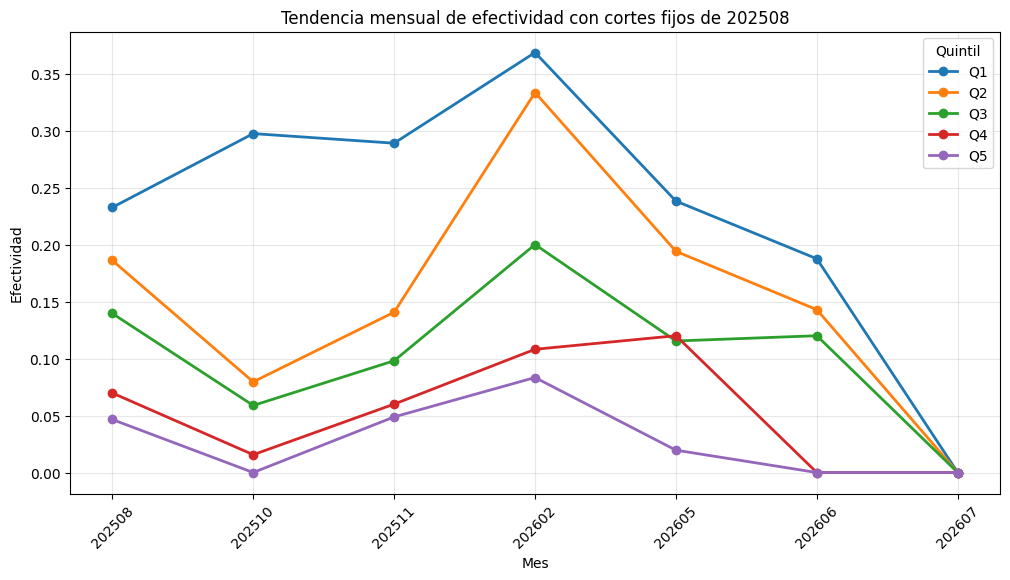

In [55]:
# ================================
# 4. Gráfico tendencia mensual
# ================================
pivot = resumen_q.pivot_table(
    index="cod_mes",
    columns="quintil_202508",
    values="efectividad"
)

plt.figure(figsize=(12,6))

for col in pivot.columns:
    plt.plot(
        pivot.index,
        pivot[col],
        marker="o",
        linewidth=2,
        label=f"Q{col}"
    )

plt.title("Tendencia mensual de efectividad con cortes fijos de 202508")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.legend(title="Quintil")
plt.xticks(rotation=45)
plt.show()

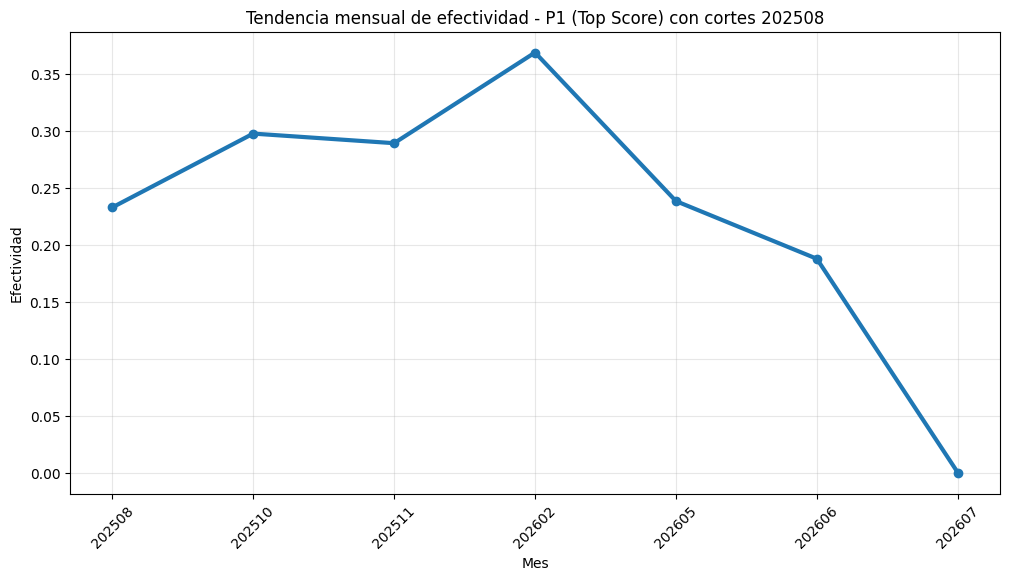

In [56]:
q1 = resumen_q[resumen_q["quintil_202508"] == 1]  # P1 = mayor score

plt.figure(figsize=(12,6))

plt.plot(
    q1["cod_mes"],
    q1["efectividad"],
    marker="o",
    linewidth=3
)

plt.title("Tendencia mensual de efectividad - P1 (Top Score) con cortes 202508")
plt.xlabel("Mes")
plt.ylabel("Efectividad")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()


In [57]:
import pandas as pd
import numpy as np

# ================================================================
# Perfilamiento por grupos de score (P1 = mayor prob, P5 = menor prob)
# ================================================================

# Columnas que NO son variables del modelo
cols_no_vars = {'key_value', 'cuc_num', 'cod_mes', 'codunico', 'codmes',
                'num_documento', 'codmes_lag1', 'tipo_alerta_n2',
                'trx_riesgo_cliente', 'target_m', 'prob',
                'quintil_202508', 'flg_alerta'}

# 1. Ordenar por prob descendente y asignar grupos P1–P5
df_perfil = df_5.sort_values("prob", ascending=False).reset_index(drop=True)
df_perfil["grupo_score"] = pd.qcut(
    df_perfil.index,
    q=5,
    labels=["P1", "P2", "P3", "P4", "P5"]
)

print(f"Distribución de grupos:")
print(df_perfil["grupo_score"].value_counts().sort_index())
print(f"\nProb media por grupo:")
print(df_perfil.groupby("grupo_score")["prob"].mean().round(4))

# 2. Variables numéricas del modelo
vars_modelo = [c for c in df_5.columns
               if c not in cols_no_vars
               and pd.api.types.is_numeric_dtype(df_5[c])]

print(f"\nVariables analizadas: {len(vars_modelo)}")

# 3. Media por grupo para cada variable
perfil = (
    df_perfil.groupby("grupo_score")[vars_modelo]
    .mean()
    .T                              # variables como filas, grupos como columnas
    .round(4)
    .reset_index()
    .rename(columns={"index": "variable"})
)

# Añadir ratio P1/P5 para ver qué variables distinguen más
perfil["ratio_P1_P5"] = (perfil["P1"] / perfil["P5"].replace(0, np.nan)).round(2)
perfil = perfil.sort_values("ratio_P1_P5", ascending=False).reset_index(drop=True)

print("\n--- Perfil de variables por grupo de score (top 30 por ratio P1/P5) ---")
display(
    perfil.head(30)
    .style
    .format({col: "{:.4f}" for col in ["P1","P2","P3","P4","P5","ratio_P1_P5"]})
    .background_gradient(subset=["P1","P2","P3","P4","P5"], cmap="RdYlGn_r", axis=1)
)

Distribución de grupos:
grupo_score
P1    416
P2    416
P3    416
P4    416
P5    416
Name: count, dtype: int64

Prob media por grupo:
grupo_score
P1    0.9738
P2    0.9203
P3    0.7965
P4    0.5107
P5    0.0906
Name: prob, dtype: float32

Variables analizadas: 0

--- Perfil de variables por grupo de score (top 30 por ratio P1/P5) ---


C:\Users\b46637\AppData\Local\Temp\ipykernel_59724\1270357413.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_perfil.groupby("grupo_score")["prob"].mean().round(4))
C:\Users\b46637\AppData\Local\Temp\ipykernel_59724\1270357413.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_perfil.groupby("grupo_score")[vars_modelo]


grupo_score,variable,P1,P2,P3,P4,P5,ratio_P1_P5


In [58]:
df_test_3.head()

,target,concentracion_dia_max,n_canales_distintos,monto_max_soles,monto_debitos_soles,ratio_debito_credito,fe_ratio_salidas_entradas,n_trx_otros,monto_transferencias_soles,imp_trx_abonosefect_12m,...,monto_total_dolares,monto_promedio_dolares,mto_dif_abn_crgsefe_6m,n_trx_pagos,tc_total_monto_mes,flg_activo,cod_mes,key_value,cuc_num,prob
0,0.0,0.666667,3.0,200.00,199.60,2.000000,0.997950,0.0,201.60,0.0,...,0.0,0.0,-3094.6,0.0,0.00,0.0,202508.0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228.0,0.012573
1,0.0,0.666667,3.0,1642.58,1642.63,2.000000,1.026637,2.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.00,1.0,202508.0,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426.0,0.010481
2,0.0,0.134615,4.0,1369.62,4117.00,1.476190,0.838078,18.0,2829.00,0.0,...,0.0,0.0,-4810.0,4.0,0.00,1.0,202508.0,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602.0,0.007718
3,0.0,0.108108,2.0,321.00,987.70,1.740741,1.034230,9.0,1379.70,720.0,...,0.0,0.0,-50.0,1.0,0.00,0.0,202508.0,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200.0,0.009579
4,0.0,0.187500,4.0,12709.00,14168.20,1.000000,1.014612,7.0,25415.15,16490.0,...,0.0,0.0,-5870.0,6.0,26327.79,1.0,202508.0,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077.0,0.119544


In [56]:
# Copias para no tocar los originales
df_final_m = df_final.copy()
df_dataset_m = df_dataset.copy()

# Normalizar claves
df_final_m["cuc_num"] = df_final_m["cuc_num"].astype(float).astype("Int64").astype(str)
df_final_m["cod_mes"] = df_final_m["cod_mes"].astype(float).astype("Int64").astype(str)

df_dataset_m["codunico"] = df_dataset_m["codunico"].astype("Int64").astype(str)
df_dataset_m["codmes"] = df_dataset_m["codmes"].astype("Int64").astype(str)

# Merge
df_merge = df_final_m.merge(
    df_dataset_m,
    how="left",
    left_on=["cuc_num", "cod_mes"],
    right_on=["codunico", "codmes"]
)

print(df_merge.shape)
df_merge.head()

(13182866, 11)


,key_value,cuc_num,prob,cod_mes,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228,0.012573,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
1,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426,0.010481,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
2,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602,0.007718,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
3,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200,0.009579,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
4,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077,0.119544,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>


In [57]:
df_merge.cod_mes.value_counts()

cod_mes
202607    2102517
202604    2086408
202605    2083507
202602    2078467
202511    1623836
202510    1610062
202508    1598069
Name: count, dtype: int64

In [58]:
# ================================================================
# Eliminar casos duplicados en df_merge
# ================================================================
candidate_keys = [
    ["key_value", "cod_mes"],
    ["key_value", "cuc_num", "cod_mes"],
    ["cuc_num", "cod_mes"],
    ["codunico", "codmes"],
]

dedup_keys = next((k for k in candidate_keys if all(col in df_merge.columns for col in k)), None)
if dedup_keys is None:
    raise ValueError("No se encontró una combinación de llaves válida para deduplicar df_merge")

before_rows = len(df_merge)

# Priorizamos conservar el registro con mayor señal de riesgo
priority_cols = [c for c in ["target_m", "prob"] if c in df_merge.columns]
if priority_cols:
    df_merge = df_merge.sort_values(priority_cols, ascending=False)

duplicates_count = df_merge.duplicated(subset=dedup_keys, keep="first").sum()
df_merge = df_merge.drop_duplicates(subset=dedup_keys, keep="first").reset_index(drop=True)
after_rows = len(df_merge)

print(f"Llaves usadas para deduplicar: {dedup_keys}")
print(f"Filas antes: {before_rows:,}")
print(f"Duplicados eliminados: {duplicates_count:,}")
print(f"Filas después: {after_rows:,}")

# Verificación por mes
df_merge.cod_mes.value_counts()

Llaves usadas para deduplicar: ['key_value', 'cod_mes']
Filas antes: 13,182,866
Duplicados eliminados: 3,255
Filas después: 13,179,611


cod_mes
202607    2102514
202604    2085558
202605    2083496
202602    2077904
202511    1622970
202510    1609433
202508    1597736
Name: count, dtype: int64

In [59]:
import pandas as pd
import numpy as np

def metricas_top_k(df, target_col, score_col, k_list):
    """
    Calcula Recall@K y Precision@K para distintos valores de K
    """
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    total_positivos = df[target_col].sum()

    resultados = []

    for k in k_list:
        top_k = df.head(k)
        tp_k = top_k[target_col].sum()

        recall_k = tp_k / total_positivos if total_positivos > 0 else 0
        precision_k = tp_k / k if k > 0 else 0

        resultados.append({
            "K": k,
            "score_min": top_k[score_col].min(),
            "TP": tp_k,
            "Recall": recall_k,
            "Precision": precision_k
        })

    return pd.DataFrame(resultados)

In [60]:
meses = [202508, 202509, 202510, 202511, 202512, 202605]
k_list = [100, 200, 500, 1000, 2000]

resultados_meses = {}

for mes in meses:
    mes_str = str(mes)  # cod_mes en df_merge es string

    test_data_alerta = df_merge[df_merge["cod_mes"] == mes_str].copy()

    if test_data_alerta.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    # prob ya existe en df_merge, no hace falta re-predecir
    tabla_k = metricas_top_k(
        test_data_alerta,
        target_col="target_m",
        score_col="prob",
        k_list=k_list
    )

    tabla_k["mes"] = mes
    resultados_meses[mes] = tabla_k
    print(f"✅ Mes {mes_str}: {len(test_data_alerta):,} registros")


✅ Mes 202508: 1,597,736 registros
⚠️ Sin datos para mes 202509
✅ Mes 202510: 1,609,433 registros
✅ Mes 202510: 1,609,433 registros
✅ Mes 202511: 1,622,970 registros
⚠️ Sin datos para mes 202512
✅ Mes 202511: 1,622,970 registros
⚠️ Sin datos para mes 202512
✅ Mes 202605: 2,083,496 registros
✅ Mes 202605: 2,083,496 registros


In [61]:
df_metricas = pd.concat(
    resultados_meses.values(),
    ignore_index=True
)

df_metricas


,K,score_min,TP,Recall,Precision,mes
0,100,0.985822,3,0.025424,0.0300,202508
1,200,0.981234,4,0.033898,0.0200,202508
2,500,0.971322,12,0.101695,0.0240,202508
3,1000,0.954586,18,0.152542,0.0180,202508
4,2000,0.925114,22,0.186441,0.0110,202508
5,100,0.986662,7,0.067308,0.0700,202510
6,200,0.982016,13,0.125000,0.0650,202510
7,500,0.971731,19,0.182692,0.0380,202510
8,1000,0.955478,28,0.269231,0.0280,202510
9,2000,0.926963,34,0.326923,0.0170,202510


In [62]:
def optimal_threshold_topk(
    df,
    score_col="prob",
    target_col="target",
    k=1000,
    n_groups=5
):
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # Total positivos reales (para recall)
    total_positivos = (df[target_col] == 1).sum()

    # Nos quedamos solo con los top K
    df_topk = df.iloc[:k].copy()

    group_size = k // n_groups
    resultados = []

    acumulado = pd.DataFrame()

    for g in range(1, n_groups + 1):
        inicio = (g - 1) * group_size
        fin = g * group_size

        acumulado = df_topk.iloc[:fin]

        tp = (acumulado[target_col] == 1).sum()
        fp = fin - tp
        fn = total_positivos - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0 else 0
        )

        threshold = acumulado[score_col].min()

        resultados.append({
            "grupo": g,
            "casos_hasta": fin,
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    return pd.DataFrame(resultados)


In [63]:
resultados_mes = {}

for mes in meses:
    mes_str = str(mes)  # cod_mes en df_merge es string

    df_mes = df_merge[df_merge["cod_mes"] == mes_str].copy()

    if df_mes.empty:
        print(f"⚠️ Sin datos para mes {mes_str}")
        continue

    # prob ya existe en df_merge, no hace falta re-predecir
    tabla = optimal_threshold_topk(
        df_mes,
        score_col="prob",
        target_col="target_m",  # columna correcta en df_merge
        k=1000,
        n_groups=5
    )

    resultados_mes[mes] = tabla
    print(f"✅ Mes {mes_str}: {len(df_mes):,} registros")


✅ Mes 202508: 1,597,736 registros
⚠️ Sin datos para mes 202509
⚠️ Sin datos para mes 202509
✅ Mes 202510: 1,609,433 registros
✅ Mes 202510: 1,609,433 registros
✅ Mes 202511: 1,622,970 registros
✅ Mes 202511: 1,622,970 registros
⚠️ Sin datos para mes 202512
⚠️ Sin datos para mes 202512
✅ Mes 202605: 2,083,496 registros
✅ Mes 202605: 2,083,496 registros


In [64]:
for mes, tabla in resultados_mes.items():
    print(f"\nMes {mes}")
    display(tabla.sort_values("f1", ascending=False).head(1))


Mes 202508


,grupo,casos_hasta,threshold,precision,recall,f1
1,2,400,0.974446,0.0275,0.09322,0.042471



Mes 202510


,grupo,casos_hasta,threshold,precision,recall,f1
0,1,200,0.982016,0.065,0.125,0.085526



Mes 202511


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.966944,0.018333,0.171875,0.033133



Mes 202605


,grupo,casos_hasta,threshold,precision,recall,f1
2,3,600,0.971259,0.028333,0.100592,0.044213


In [65]:
df_optimos = []

for mes, tabla in resultados_mes.items():
    best = tabla.sort_values("f1", ascending=False).iloc[0]
    best["mes"] = mes
    df_optimos.append(best)

df_optimos = pd.DataFrame(df_optimos)
df_optimos

,grupo,casos_hasta,threshold,precision,recall,f1,mes
1,2.0,400.0,0.974446,0.027500,0.093220,0.042471,202508.0
0,1.0,200.0,0.982016,0.065000,0.125000,0.085526,202510.0
2,3.0,600.0,0.966944,0.018333,0.171875,0.033133,202511.0
2,3.0,600.0,0.971259,0.028333,0.100592,0.044213,202605.0


In [66]:
# ================================================================
# Threshold final: percentil 75 de los thresholds óptimos por mes
# Cada mes aporta el score mínimo que maximizó F1 en ese mes.
# p75 → más restrictivo que el óptimo del 75% de los meses
#        → menos alertas, mayor precision
# ================================================================
threshold_final = df_optimos["threshold"].quantile(0.75)

print(f"Threshold final (p75): {threshold_final:.4f}\n")
print(f"Thresholds óptimos por mes (los que maximizan F1):")
display(df_optimos[["mes", "threshold", "precision", "recall", "f1"]])

print(f"\nImpacto del threshold {threshold_final:.4f} por mes:")
resumen_final = (
    df_merge[df_merge["prob"] >= threshold_final]
    .groupby("cod_mes")
    .agg(
        alertas=("prob", "count"),
        positivos=("target_m", "sum")
    )
    .assign(precision=lambda d: (d["positivos"] / d["alertas"]).round(3))
)
resumen_final.index = resumen_final.index.astype(str)
display(resumen_final)


Threshold final (p75): 0.9763

Thresholds óptimos por mes (los que maximizan F1):


,mes,threshold,precision,recall,f1
1,202508.0,0.974446,0.027500,0.093220,0.042471
0,202510.0,0.982016,0.065000,0.125000,0.085526
2,202511.0,0.966944,0.018333,0.171875,0.033133
2,202605.0,0.971259,0.028333,0.100592,0.044213



Impacto del threshold 0.9763 por mes:


,alertas,positivos,precision
cod_mes,,,
202508,342,9,0.026
202510,354,16,0.045
202511,335,6,0.018
202602,424,27,0.064
202604,399,19,0.048
202605,438,11,0.025
202607,121,0,0.0


In [67]:
#pILOTO

In [68]:
%%time
query = """

WITH pd AS (
    SELECT DISTINCT
        -- Identificadores
        a.key_value,
        a.cod_cli,
        date_format(
            date_parse(CAST(a.cod_mes AS varchar), '%Y%m') + interval '1' month,
            '%Y%m'
        ) AS codmes_lag1,
        CAST(a.cod_mes AS INTEGER) AS codmes

    

    FROM e_perm_aws.t_agg_alertas_plaft a
    WHERE a.cod_mes = '202607'
      AND a.desc_subsegmento  IN ('Masivo', 'Masivo Dependiente', 'Masivo Independiente')
),

target AS (
 SELECT *
FROM (
    SELECT
        codunico,
        CAST(REPLACE(SUBSTRING(CAST(alerta_fecha AS VARCHAR),1,7),'-','') AS VARCHAR) AS periodo_alerta,
        tipo_alerta_n2,
        trx_riesgo_cliente,
        ROW_NUMBER() OVER (
            PARTITION BY codunico,
                         REPLACE(SUBSTRING(CAST(alerta_fecha AS VARCHAR),1,7),'-','')
            ORDER BY CASE
                WHEN tipo_alerta_n2 = 'MANUAL' THEN 1
                WHEN tipo_alerta_n2 = 'SEMI AUTOMATICA' THEN 2
                WHEN tipo_alerta_n2 = 'AUTOMATICA' THEN 3
                ELSE 99
            END
        ) AS rn,
        MAX(CAST (orden_alerta AS INT )) AS flg_alerta
    FROM e_perm_aws.t_alertas_plaft
    GROUP BY
        codunico,
        REPLACE(SUBSTRING(CAST(alerta_fecha AS VARCHAR),1,7),'-',''),
        tipo_alerta_n2,
        trx_riesgo_cliente
) t
WHERE rn = 1)

SELECT 
    a.*,
    b.tipo_alerta_n2,
    b.trx_riesgo_cliente,
    CASE 
        WHEN b.flg_alerta = 1 THEN 1 
        ELSE 0 
    END AS target_m,
    b.periodo_alerta,
    a.codmes as periodo
FROM pd a
LEFT JOIN target b
    ON a.cod_cli = b.codunico
    AND cast(a.codmes_lag1 as varchar) = b.periodo_alerta

;"""
df_alerta = athena_query(query, database='disc_comercial')
df_alerta.head()


CPU times: total: 21.4 s
Wall time: 4min 12s


,key_value,cod_cli,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m,periodo_alerta,periodo
0,4211F1B9FC3F1C089DEC6788E8CE83CDDAC1523C1871C4...,0011884641,202608,202607,<NA>,<NA>,0,<NA>,202607
1,E113433E870E7F714B24D26A297E2BC96C6A487316EEED...,0013335679,202608,202607,<NA>,<NA>,0,<NA>,202607
2,137FE556E896F26FCA01EE18616F15123772801D6E5AB4...,0010321273,202608,202607,<NA>,<NA>,0,<NA>,202607
3,691A4E91DED38367323F11A789E3648892A456D74654BE...,0008247830,202608,202607,<NA>,<NA>,0,<NA>,202607
4,1BE49B364FDFCA1639445EEAD056B76F235A5DB66E1F5F...,0011517954,202608,202607,<NA>,<NA>,0,<NA>,202607


In [69]:
# Copias para no tocar los originales
df_final_m = df_final.copy()
df_dataset_m = df_dataset.copy()

# Normalizar claves
df_final_m["cuc_num"] = df_final_m["cuc_num"].astype(float).astype("Int64").astype(str)
df_final_m["cod_mes"] = df_final_m["cod_mes"].astype(float).astype("Int64").astype(str)

df_dataset_m["codunico"] = df_dataset_m["codunico"].astype("Int64").astype(str)
df_dataset_m["codmes"] = df_dataset_m["codmes"].astype("Int64").astype(str)

# Merge
df_6 = df_final_m.merge(
    df_dataset_m,
    how="left",
    left_on=["cuc_num", "cod_mes"],
    right_on=["codunico", "codmes"]
)

# Excluir clientes que ya aparecen en df_alerta
# df_alerta usa cod_cli (de t_agg_alertas_plaft), que equivale a cuc_num
col_id_alerta = next(
    (c for c in ['cod_cli', 'codunico', 'cuc_num'] if c in df_alerta.columns),
    None
)
if col_id_alerta:
    clientes_alerta = df_alerta[col_id_alerta].astype(str).unique()
    antes = len(df_6)
    df_6 = df_6[~df_6["cuc_num"].isin(clientes_alerta)].copy()
    print(f"Columna usada para exclusión   : '{col_id_alerta}'")
    print(f"Clientes en df_alerta          : {len(clientes_alerta):,}")
    print(f"Filas antes de excluir         : {antes:,}")
    print(f"Filas después de excluir       : {len(df_6):,}  ({antes - len(df_6):,} eliminadas)")
else:
    print("⚠️  df_alerta no tiene columna de id reconocida — no se aplicó exclusión")
    print(f"   Columnas disponibles: {df_alerta.columns.tolist()}")

print(df_6.shape)
df_6.head()


Columna usada para exclusión   : 'cod_cli'
Clientes en df_alerta          : 6,358,050
Filas antes de excluir         : 13,182,866
Filas después de excluir       : 13,182,866  (0 eliminadas)
(13182866, 11)


,key_value,cuc_num,prob,cod_mes,num_documento,codunico,codmes_lag1,codmes,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,5835EE83223726CEF7803355E801FB3A599935E56DABF7...,17610228,0.012573,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
1,92F03B46DEDB989AB1D3A95A83693584CC748C705F82E0...,15305426,0.010481,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
2,2C45F5616B8997F0D16F193888BC1330AAA9ADD7AA24B8...,16679602,0.007718,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
3,6BBBFD9D852374BDD59EA10EFD1E2FFF409291C7251F16...,21132200,0.009579,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>
4,B944C9DF83D59EEE5BF4C45A0883492087310A075E04D9...,13934077,0.119544,202508,<NA>,NaN,<NA>,NaN,<NA>,<NA>,<NA>


In [70]:

# ================================================================
# PILOTO — Mes 202607
# Criterios:
#   1. cod_mes == '202607'           → mes del piloto
#   2. prob > 0.9729                 → threshold final del modelo
#   3. tipo_alerta_n2 es nula        → clientes SIN alerta previa (nuevos a alertar)
# ================================================================

THRESHOLD_PILOTO =  0.9763
MES_PILOTO       = '202607'

# Normalizar cod_mes a string por si viene como float
df_6['cod_mes'] = df_6['cod_mes'].astype(str).str.split('.').str[0].str.strip()

df_piloto = df_6[
    (df_6['cod_mes'] == MES_PILOTO) &
    (df_6['prob'] > THRESHOLD_PILOTO) &
    (df_6['tipo_alerta_n2'].isna())
].copy().sort_values('prob', ascending=False).reset_index(drop=True)

print(f"═" * 60)
print(f"  PILOTO PLAFT Masivo PN — Mes {MES_PILOTO}")
print(f"  Threshold: {THRESHOLD_PILOTO}  |  Alertas sin expediente previo")
print(f"═" * 60)
print(f"\n  Clientes seleccionados : {len(df_piloto):,}")
print(f"  Score mínimo           : {df_piloto['prob'].min():.4f}")
print(f"  Score máximo           : {df_piloto['prob'].max():.4f}")
print(f"  Score mediano          : {df_piloto['prob'].median():.4f}")

# Columnas de salida para el piloto
cols_salida = [c for c in ['cuc_num', 'cod_mes', 'prob', 'key_value',
                            'num_documento', 'codunico',
                            'tipo_alerta_n2', 'trx_riesgo_cliente', 'target_m']
               if c in df_piloto.columns]

print(f"\n  Columnas disponibles   : {cols_salida}")
print()
display(df_piloto[cols_salida].head(10))

# Exportar a CSV
output_piloto = r'C:\Users\b46637\OneDrive - Interbank\PLAFT\Masivo\Desarrollo\piloto_202607.csv'
df_piloto[cols_salida].to_csv(output_piloto, index=False, encoding='utf-8-sig')
print(f"\n✅ Piloto exportado: {output_piloto}")
print(f"   {len(df_piloto):,} registros")


════════════════════════════════════════════════════════════
  PILOTO PLAFT Masivo PN — Mes 202607
  Threshold: 0.9763  |  Alertas sin expediente previo
════════════════════════════════════════════════════════════

  Clientes seleccionados : 122
  Score mínimo           : 0.9763
  Score máximo           : 0.9977
  Score mediano          : 0.9819

  Columnas disponibles   : ['cuc_num', 'cod_mes', 'prob', 'key_value', 'num_documento', 'codunico', 'tipo_alerta_n2', 'trx_riesgo_cliente', 'target_m']



,cuc_num,cod_mes,prob,key_value,num_documento,codunico,tipo_alerta_n2,trx_riesgo_cliente,target_m
0,21570404,202607,0.997656,660FCB9294C00F7FA4D9014D3B89FB35B84AFD1C85DB3B...,<NA>,NaN,<NA>,<NA>,<NA>
1,21980712,202607,0.993351,8158A1F41F1692AD5E4939FFBBF7299F3ECF24F5EC846A...,<NA>,NaN,<NA>,<NA>,<NA>
2,13712823,202607,0.990289,F14B867CAD528A4CFADDEB4B2F61EA38C62C9196A4924B...,<NA>,NaN,<NA>,<NA>,<NA>
3,21496800,202607,0.989758,463230882DED4D8E2EFA2F71EB1DE6C41E8CE9603C1EBF...,<NA>,NaN,<NA>,<NA>,<NA>
4,22208678,202607,0.989180,B67071F01A8C8D90F1FB7A5E0E00F43D8D05CB7299BE1C...,<NA>,NaN,<NA>,<NA>,<NA>
5,21470996,202607,0.988900,D720AD3B60D1BC1DD6C803E980E4B9108B44B1088E8106...,<NA>,NaN,<NA>,<NA>,<NA>
6,16818194,202607,0.988775,59EA11775D981518AC876C378E59D5E0C6C85C4DDC7500...,<NA>,NaN,<NA>,<NA>,<NA>
7,16403641,202607,0.988747,0282E24A926B5E83A963154B529EFA0EE04DCB8BBB101D...,<NA>,NaN,<NA>,<NA>,<NA>
8,18585692,202607,0.988400,AE3EC25FD74D4B2B7DA52AD6681ADE38CA715C2B3CE83A...,<NA>,NaN,<NA>,<NA>,<NA>
9,21817672,202607,0.988301,B981FC5BD5FF3A9960E7C73B8B8A8114C575B5E417868A...,<NA>,NaN,<NA>,<NA>,<NA>



✅ Piloto exportado: C:\Users\b46637\OneDrive - Interbank\PLAFT\Masivo\Desarrollo\piloto_202607.csv
   122 registros


In [71]:
#Perfilamiento

In [32]:
len(df_test_3)

6358050

In [ ]:
# Buscar cualquier cuc_num que contenga el valor indicado
CLIENTE_BUSCADO = '19755061.00'
COLUMNAS_MOSTRAR = ['key_value', 'cuc_num', 'cod_mes', 'target']

for nombre_df, df in [('df_test', df_test), ('df_test_3', df_test_3)]:
    columnas_disponibles = [columna for columna in COLUMNAS_MOSTRAR if columna in df.columns]
    ids = df['cuc_num'].astype('string')
    resultado = df.loc[ids.str.contains(CLIENTE_BUSCADO, na=False, regex=False), columnas_disponibles].copy()
    print(f'{nombre_df}: {len(resultado):,} registros encontrados')
    display(resultado)

print(f'Valor buscado dentro de cuc_num: {CLIENTE_BUSCADO}')

df_test: 7 registros encontrados


,key_value,cuc_num,cod_mes,target
104038,F6C6B926C8D9622FC2253EBF8DDA5D792FDB25D3C129CD...,19755064.0,202607.0,0.0
1119290,010B1CA5FFEF3294351C7C7C1E5BA52157CE3BAB1EF387...,21975506.0,202607.0,0.0
1483469,88E7A4ED573E370F28C9C3D2CC1CAF7ADB181ECE675446...,19755064.0,202607.0,0.0
2073365,5CD176825CF45831071B3141DE64B372D438FD17BEE683...,11975506.0,202607.0,0.0
2410571,D6ACA953208127AD7B80610A735DC20B6BB9087C5F5A71...,19755068.0,202607.0,0.0
2445249,59519AB9681785F014F75486282BB0258E14F93D79792D...,19755060.0,202607.0,0.0
3857964,0A98EDB9C6D48C67EB1F57CAA48C847A160E0D4EF7CFA0...,19755062.0,202607.0,0.0


df_test_3: 7 registros encontrados


,key_value,cuc_num,cod_mes,target
104038,F6C6B926C8D9622FC2253EBF8DDA5D792FDB25D3C129CD...,19755064.0,202607.0,0.0
1119290,010B1CA5FFEF3294351C7C7C1E5BA52157CE3BAB1EF387...,21975506.0,202607.0,0.0
1483469,88E7A4ED573E370F28C9C3D2CC1CAF7ADB181ECE675446...,19755064.0,202607.0,0.0
2073365,5CD176825CF45831071B3141DE64B372D438FD17BEE683...,11975506.0,202607.0,0.0
2410571,D6ACA953208127AD7B80610A735DC20B6BB9087C5F5A71...,19755068.0,202607.0,0.0
2445249,59519AB9681785F014F75486282BB0258E14F93D79792D...,19755060.0,202607.0,0.0
3857964,0A98EDB9C6D48C67EB1F57CAA48C847A160E0D4EF7CFA0...,19755062.0,202607.0,0.0


Valor buscado dentro de cuc_num: 1975506


In [48]:
# Conteo de casos con cuc_num == 0
for nombre_df, df in [('df_test', df_test), ('df_test_3', df_test_3)]:
    cuc_num_num = pd.to_numeric(df['cuc_num'], errors='coerce')
    n_cero = int(cuc_num_num.eq(0).sum())
    print(f'{nombre_df}: {n_cero:,} casos con cuc_num = 0')

df_test: 0 casos con cuc_num = 0
df_test_3: 0 casos con cuc_num = 0


In [35]:
# Join eficiente en memoria: alertas_0726.csv como base principal
# Busca primero 202607 y luego meses anteriores sin copiar df_test_3 completo.
from pathlib import Path
import pandas as pd
import numpy as np

MES_CRUCE = 202607
MESES_BUSQUEDA = [
    202607, 202606, 202605, 202604, 202603,
    202602, 202601, 202512, 202511, 202510,
    202509, 202508
]
RUTA_ALERTAS = Path(r"C:\Users\b46637\OneDrive - Interbank\PLAFT\Interbank\PLAFT\Masivo\Desarrollo\alertas_0726.csv")
RUTA_SALIDA = Path(r"C:\Users\b46637\OneDrive - Interbank\PLAFT\Interbank\PLAFT\Masivo\Desarrollo\alertas_0726_con_score_y_P.csv")

if 'df_test_3' not in globals():
    raise NameError("No existe df_test_3. Ejecuta primero la celda de predicción.")
if not {'cuc_num', 'cod_mes', 'prob'}.issubset(df_test_3.columns):
    raise KeyError("df_test_3 debe contener las columnas 'cuc_num', 'cod_mes' y 'prob'.")
if not RUTA_ALERTAS.exists():
    raise FileNotFoundError(f"No existe la base de alertas: {RUTA_ALERTAS}")

alertas = pd.read_csv(RUTA_ALERTAS, dtype=str)
alertas.columns = alertas.columns.str.strip()
if 'CLIENTE' not in alertas.columns:
    raise KeyError(f"La base de alertas debe contener 'CLIENTE'. Columnas: {alertas.columns.tolist()}")

def normalizar_id(serie):
    return (
        pd.to_numeric(serie, errors='coerce')
        .astype('Int64')
        .astype(str)
        .replace('<NA>', '')
        .str.strip()
    )

alertas['_id_cruce'] = normalizar_id(alertas['CLIENTE'])
alertas = alertas[alertas['_id_cruce'] != ''].copy()
ids_pendientes = set(alertas['_id_cruce'])

# Diccionario pequeño: solo guarda clientes de alertas encontrados.
filas_modelo = []
for mes in MESES_BUSQUEDA:
    if not ids_pendientes:
        break

    mask_mes = pd.to_numeric(df_test_3['cod_mes'], errors='coerce').eq(mes)
    candidatos = df_test_3.loc[mask_mes, ['cuc_num', 'cod_mes', 'prob']]
    if candidatos.empty:
        continue

    candidatos = candidatos.copy()
    candidatos['_id_cruce'] = normalizar_id(candidatos['cuc_num'])
    candidatos = candidatos[
        candidatos['_id_cruce'].isin(ids_pendientes)
    ].drop_duplicates('_id_cruce', keep='first')

    if candidatos.empty:
        continue

    candidatos['mes_score'] = mes
    filas_modelo.append(candidatos)
    ids_pendientes.difference_update(candidatos['_id_cruce'])

if filas_modelo:
    modelo_join = pd.concat(filas_modelo, ignore_index=True)
else:
    modelo_join = pd.DataFrame(columns=['_id_cruce', 'cuc_num', 'cod_mes', 'prob', 'mes_score'])

# La base de alertas determina las filas finales del resultado.
resultado_alertas_0726 = alertas.merge(
    modelo_join,
    on='_id_cruce',
    how='left',
    indicator=True
)

resultado_alertas_0726['P'] = ''
mask_encontrado = resultado_alertas_0726['_merge'].eq('both')

# Cortes entregados: el intervalo superior representa P1 y el inferior P5.
cortes = [-np.inf, 0.222, 0.631, 0.855, 0.954, 0.992]
labels = ['P5', 'P4', 'P3', 'P2', 'P1']
resultado_alertas_0726.loc[mask_encontrado, 'P'] = pd.cut(
    pd.to_numeric(resultado_alertas_0726.loc[mask_encontrado, 'prob'], errors='coerce'),
    bins=cortes,
    labels=labels,
    include_lowest=True,
    right=True
).astype('string').fillna('')

resultado_alertas_0726 = resultado_alertas_0726.drop(
    columns=['_id_cruce', '_merge']
)
resultado_alertas_0726.to_csv(
    RUTA_SALIDA,
    index=False,
    encoding='utf-8-sig'
)

print(f"Base principal: {RUTA_ALERTAS}")
print(f"Mes limite de busqueda: {MES_CRUCE}")
print(f"Meses revisados: {MESES_BUSQUEDA}")
print(f"Registros de alertas: {len(alertas):,}")
print(f"Coincidencias usando 202607 o meses anteriores: {int(mask_encontrado.sum()):,}")
print(f"Sin coincidencia en ningun mes: {int((~mask_encontrado).sum()):,}")
print(f"Archivo guardado: {RUTA_SALIDA}")
display(resultado_alertas_0726.head(10))

Base principal: C:\Users\b46637\OneDrive - Interbank\PLAFT\Interbank\PLAFT\Masivo\Desarrollo\alertas_0726.csv
Mes limite de busqueda: 202607
Meses revisados: [202607, 202606, 202605, 202604, 202603, 202602, 202601, 202512, 202511, 202510, 202509, 202508]
Registros de alertas: 1,967
Coincidencias usando 202607 o meses anteriores: 1,586
Sin coincidencia en ningun mes: 381
Archivo guardado: C:\Users\b46637\OneDrive - Interbank\PLAFT\Interbank\PLAFT\Masivo\Desarrollo\alertas_0726_con_score_y_P.csv


,CLIENTE,cuc_num,cod_mes,prob,mes_score,P
0,19755061,NaN,NaN,NaN,NaN,
1,15694204,15694204.0,202607.0,0.123466,202607.0,P5
2,12845177,12845177.0,202607.0,0.788530,202607.0,P3
3,20159298,20159298.0,202607.0,0.404948,202607.0,P4
4,10296451,10296451.0,202607.0,0.652169,202607.0,P3
5,17865125,NaN,NaN,NaN,NaN,
6,15625516,15625516.0,202607.0,0.884209,202607.0,P2
7,15501904,15501904.0,202607.0,0.917310,202607.0,P2
8,20287204,20287204.0,202607.0,0.003590,202607.0,P5
9,17020474,17020474.0,202607.0,0.044784,202607.0,P5


📊 Perfilamiento | Mes: 202607.0 | Clientes: 13,182,690
   Score mediano  →  P1 (mayor riesgo): 0.0670  |  P5 (menor riesgo): 0.0030

   Tasa de alertas reales por quintil:
   Score mediano  →  P1 (mayor riesgo): 0.0670  |  P5 (menor riesgo): 0.0030

   Tasa de alertas reales por quintil:
     P1:  0.06%  
     P1:  0.06%  
     P2:  0.00%  
     P2:  0.00%  
     P3:  0.00%  
     P3:  0.00%  
     P4:  0.00%  
     P4:  0.00%  
     P5:  0.00%  
     P5:  0.00%  

════════════════════════════════════════════════════════════════════════════════
  PERFILAMIENTO  |  Variables del modelo agrupadas por categoría
  Rojo = P1 (mayor riesgo)  |  Verde = P5 (menor riesgo)  |  P1/P5 = razón de diferencia
════════════════════════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════════════════════════
  PERFILAMIENTO  |  Variables del modelo agrupadas por categoría
  Rojo = P1 (mayor riesgo)  |  Verde = P5 (menor riesgo)  |  P1/P5 

Grupo,Variable,P1 – Alto,P2,P3,P4,P5 – Bajo,P1/P5
🧑 Perfil del Cliente,Antigüedad del cliente (meses),10.0,9.000,9.000,9.000,9.000,1.1×
🧑 Perfil del Cliente,% con productos activos,45.7%,41.8%,38.1%,36.8%,27.3%,1.7×
💵 Actividad en Efectivo,Monto depositado efectivo 12m (S/),"3,500.0",0.00000,0.00000,0.00000,0.00000,–
💵 Actividad en Efectivo,N° depósitos en efectivo 12m,2.000,0.00000,0.00000,0.00000,0.00000,–
💵 Actividad en Efectivo,Monto efectivo en el mes (S/),0.00000,0.00000,0.00000,0.00000,0.00000,–
💵 Actividad en Efectivo,N° transacciones en efectivo (mes),0.00000,0.00000,0.00000,0.00000,0.00000,–
💵 Actividad en Efectivo,Proporción efectivo / total operado,0.00000,0.00000,0.00000,0.00000,0.00000,–
💵 Actividad en Efectivo,Dif. depósitos vs egresos efectivo 6m (S/),0.00000,0.00000,0.00000,0.00000,0.00000,–
💵 Actividad en Efectivo,Ratio monto depósitos efectivo 6m,0.00151,0.00000,0.00000,0.00000,0.00000,–
💵 Actividad en Efectivo,Diferencia operaciones efectivo 6m,0.00000,0.00000,0.00000,0.00000,0.00000,–


C:\Users\b46637\AppData\Local\Temp\ipykernel_17428\3396316135.py:304: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\b46637\AppData\Local\Temp\ipykernel_17428\3396316135.py:305: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig('perfilamiento_quintiles.png', dpi=150, bbox_inches='tight')
C:\Users\b46637\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\b46637\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


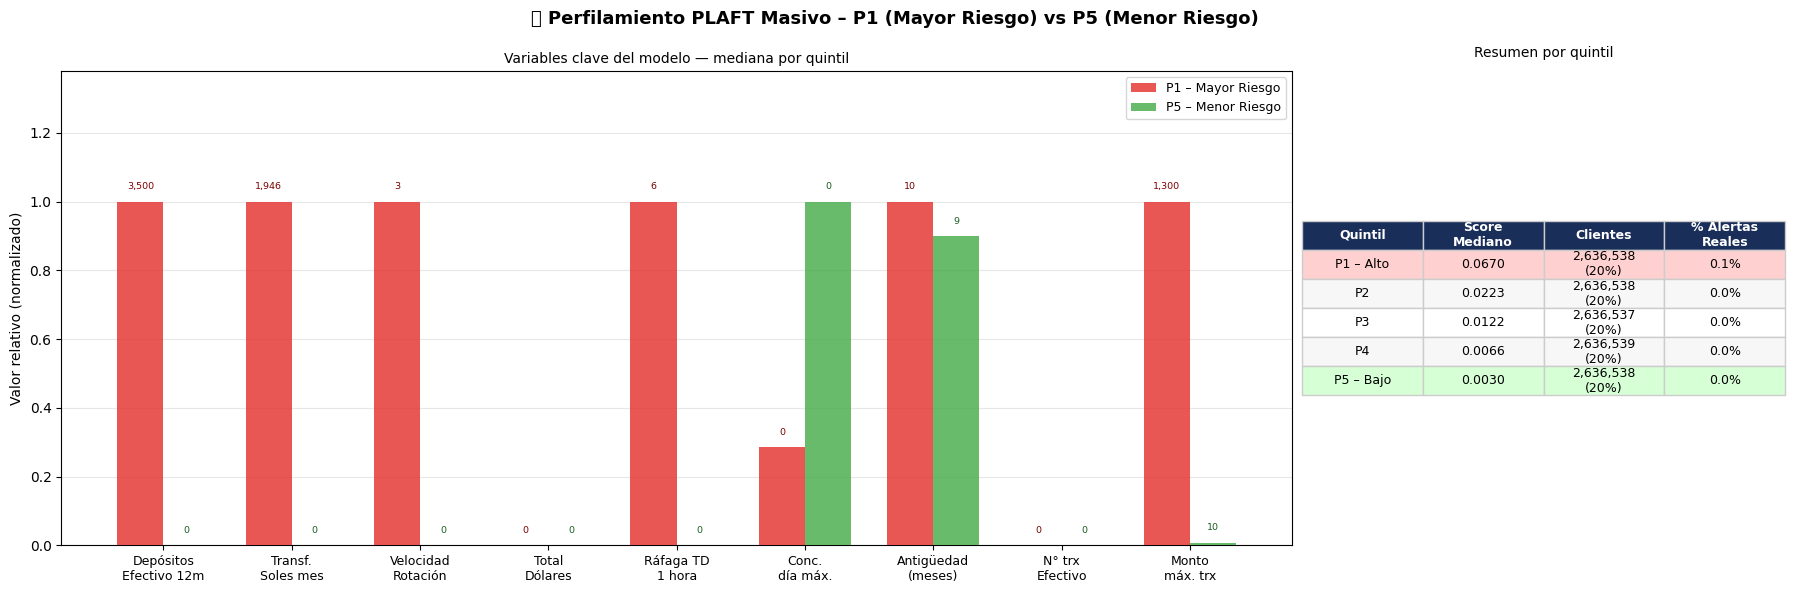


════════════════════════════════════════════════════════════════════════════════
  SÍNTESIS DEL PERFIL — P1 (Mayor Riesgo) vs P5 (Menor Riesgo)
════════════════════════════════════════════════════════════════════════════════

  [Perfil del Cliente]
    • Antigüedad del cliente: P1=10.0 → P5=9.0

  [Perfil del Cliente]
    • Antigüedad del cliente: P1=10.0 → P5=9.0

  [Efectivo]
    • Monto total depositado en efectivo (12m): P1=3,500.0 → P5=0.0
    • Número de transacciones en efectivo: P1=0.0 → P5=0.0
    • Proporción efectivo sobre total: P1=0.0 → P5=0.0

  [Efectivo]
    • Monto total depositado en efectivo (12m): P1=3,500.0 → P5=0.0
    • Número de transacciones en efectivo: P1=0.0 → P5=0.0
    • Proporción efectivo sobre total: P1=0.0 → P5=0.0

  [Cargos / Egresos]
    • Monto anual egresos en efectivo: P1=3,690.4 → P5=0.0

  [Cargos / Egresos]
    • Monto anual egresos en efectivo: P1=3,690.4 → P5=0.0

  [Intensidad Fondos]
    • Intensidad de uso de fondos: P1=3.4 → P5=0.0
    

In [73]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display, HTML

# ================================================================
# PERFILAMIENTO GERENCIAL POR QUINTIL DE SCORE PLAFT
# P1 = mayor score (mayor riesgo)  |  P5 = menor score (menor riesgo)
# ================================================================

# ── 1. Quintiles de score ────────────────────────────────────────
df_perfil = df_test_3.copy()
df_perfil['cod_mes'] = df_perfil['cod_mes'].astype(str).str.strip()
# labels=[5,4,3,2,1] → bin más alto de prob recibe label 1 (P1=mayor riesgo)
df_perfil['quintil'] = pd.qcut(df_perfil['prob'], 5, labels=[5, 4, 3, 2, 1]).astype(int)
Q_MAP = {1: 'P1 – Alto', 2: 'P2', 3: 'P3', 4: 'P4', 5: 'P5 – Bajo'}
df_perfil['grupo_score'] = df_perfil['quintil'].map(Q_MAP)

mes_activo = df_perfil['cod_mes'].mode()[0]
print(f"📊 Perfilamiento | Mes: {mes_activo} | Clientes: {len(df_perfil):,}")
print(f"   Score mediano  →  P1 (mayor riesgo): {df_perfil[df_perfil['quintil']==1]['prob'].median():.4f}"
      f"  |  P5 (menor riesgo): {df_perfil[df_perfil['quintil']==5]['prob'].median():.4f}")

if 'target' in df_perfil.columns:
    print("\n   Tasa de alertas reales por quintil:")
    for q in [1, 2, 3, 4, 5]:
        sub  = df_perfil[df_perfil['quintil'] == q]
        tasa = sub['target'].mean() * 100
        bar  = '█' * int(tasa / 2) if tasa > 0 else ''
        print(f"     P{q}: {tasa:5.2f}%  {bar}")

# ================================================================
# 2. Grupos temáticos (basados en secciones del query_test.sql)
# ================================================================
GRUPOS = {
    '🧑 Perfil del Cliente': [
        ('num_antiguedad',              'Antigüedad del cliente (meses)',           'median'),
        ('flg_activo',                  '% con productos activos',                  'pct'),
    ],
    '💵 Actividad en Efectivo': [
        ('imp_trx_abonosefect_12m',     'Monto depositado efectivo 12m (S/)',        'median'),
        ('cnt_trx_abonosefect_12m',     'N° depósitos en efectivo 12m',             'median'),
        ('monto_efectivo_soles',        'Monto efectivo en el mes (S/)',             'median'),
        ('n_trx_efectivo',              'N° transacciones en efectivo (mes)',        'median'),
        ('fe_ratio_efectivo_vs_total',  'Proporción efectivo / total operado',      'median'),
        ('mto_dif_abn_crgsefe_6m',      'Dif. depósitos vs egresos efectivo 6m (S/)', 'median'),
        ('rat_trx_mntabnsefetot_6m',    'Ratio monto depósitos efectivo 6m',        'median'),
        ('cnt_dif_abn_crgsefe_6m',      'Diferencia operaciones efectivo 6m',       'median'),
        ('flg_vrcn_abonos_5m_1m',       '% con incremento reciente de depósitos',   'pct'),
    ],
    '📤 Flujo de Egresos': [
        ('imp_trx_cargostot_1m',        'Monto egresos totales último mes (S/)',     'median'),
        ('imp_trx_cargosefe_12m',       'Monto egresos en efectivo 12m (S/)',        'median'),
        ('cnt_trx_cargostot_12m',       'N° egresos totales 12m',                   'median'),
        ('fe_zscore_cargos',            'Atipicidad en nivel de egresos (z-score)',  'median'),
        ('monto_debitos_soles',         'Monto egresos en soles (mes S/)',           'median'),
        ('cnt_trx_abonostot_12m',       'N° depósitos totales 12m',                 'median'),
    ],
    '⚡ Intensidad de Uso de Fondos': [
        ('fe_velocidad_rotacion',       'Velocidad de rotación de fondos',           'median'),
        ('concentracion_dia_max',       'Concentración máx. de trx por día',        'median'),
        ('ratio_debito_credito',        'Ratio egresos / depósitos',                'median'),
        ('fe_ratio_salidas_entradas',   'Ratio salidas / entradas de fondos',       'median'),
    ],
    '🔄 Transferencias y Canales': [
        ('monto_transferencias_soles',  'Monto transferencias en soles (mes S/)',    'median'),
        ('n_trx_mismo_cliente',         'Transferencias entre cuentas propias',      'median'),
        ('n_canales_distintos',         'Canales distintos utilizados',              'median'),
        ('n_trx_app',                   'N° transacciones por APP',                 'median'),
        ('n_trx_pagos',                 'N° pagos realizados',                      'median'),
        ('n_trx_otros',                 'N° transacciones diversas',                'median'),
    ],
    '💱 Dólares y Montos Altos': [
        ('monto_total_dolares',         'Monto total operado en dólares (mes USD)',  'median'),
        ('monto_promedio_dolares',      'Monto promedio por transacción (USD)',      'median'),
        ('monto_max_soles',             'Monto máximo por transacción (S/)',         'median'),
    ],
    '💳 Tarjeta de Débito': [
        ('td_avg_monto_1h',             'Monto promedio en ráfaga de 1 hora (S/)',  'median'),
        ('td_monto_total',              'Monto total tarjeta débito (mes S/)',       'median'),
        ('td_gap_promedio',             'Minutos promedio entre usos de TD',        'median'),
    ],
    '🏦 Tarjeta de Crédito': [
        ('tc_total_monto_mes',          'Monto total tarjeta crédito (mes S/)',      'median'),
    ],
}

VARS_NO_EN_MODELO = [
    'mto_al_ext_12m (envíos al exterior)',
    'mto_del_ext_12m (recepción del exterior)',
    'cnt_ros_hist (historial de ROS)',
    'flg_pep (exposición PEP)',
    'imp_trx_debajo10k_ing_12m (estructuración)',
    'mto_cp_tot_ing_ros (contrapartes con riesgo)',
]

# ================================================================
# 3. Calcular mediana / % por quintil para cada variable
# ================================================================
Q_COLS = [1, 2, 3, 4, 5]
Q_LABS = ['P1 – Alto', 'P2', 'P3', 'P4', 'P5 – Bajo']

def fmt_val(val, agg):
    if agg == 'pct':
        return f'{val * 100:.1f}%'
    if abs(val) >= 100_000:
        return f'{val:,.0f}'
    elif abs(val) >= 10_000:
        return f'{val:,.0f}'
    elif abs(val) >= 10:
        return f'{val:,.1f}'
    elif abs(val) >= 0.01:
        return f'{val:.3f}'
    else:
        return f'{val:.5f}'

filas = []
for grupo, variables in GRUPOS.items():
    for col, label, agg in variables:
        if col not in df_perfil.columns:
            continue
        fila = {'Grupo': grupo, 'Variable': label}
        for qnum, qlab in zip(Q_COLS, Q_LABS):
            sub = df_perfil[df_perfil['quintil'] == qnum][col].dropna()
            val = sub.mean() if agg == 'pct' else sub.median()
            fila[qlab] = fmt_val(val, agg)
        filas.append(fila)

df_tabla = pd.DataFrame(filas)

# ── Razón de cambio P1 / P5 ──────────────────────────────────────
razones = []
for grupo, variables in GRUPOS.items():
    for col, label, agg in variables:
        if col not in df_perfil.columns:
            continue
        v1 = df_perfil[df_perfil['quintil'] == 1][col].dropna()
        v5 = df_perfil[df_perfil['quintil'] == 5][col].dropna()
        base = (v5.mean() if agg == 'pct' else v5.median())   # P5 = base (menor riesgo)
        top  = (v1.mean() if agg == 'pct' else v1.median())   # P1 = alto riesgo
        if abs(base) > 1e-6:
            razon = top / base
            razon_str = f'{razon:.1f}×'
        else:
            razon_str = '–'
        razones.append(razon_str)

df_tabla['P1/P5'] = razones

# ================================================================
# 4. Renderizar tabla con estilos
# ================================================================
def _colorear(row):
    estilos = []
    for col in row.index:
        if col == 'P1 – Alto':
            estilos.append('background-color:#FFD0D0;font-weight:bold;color:#7B0000')
        elif col == 'P5 – Bajo':
            estilos.append('background-color:#D6FFD6;font-weight:bold;color:#1B5E20')
        elif col == 'P1/P5':
            estilos.append('background-color:#FFF8E1;font-style:italic;color:#5D4037')
        elif col == 'Grupo':
            estilos.append('background-color:#EEF2FA;font-weight:bold;font-style:italic')
        else:
            estilos.append('')
    return estilos

tabla_styled = (
    df_tabla.style
    .apply(_colorear, axis=1)
    .set_table_styles([
        {'selector': 'table',
         'props': [('border-collapse', 'collapse'), ('width', '100%'),
                   ('font-family', 'Arial,sans-serif')]},
        {'selector': 'thead tr th',
         'props': [('background-color', '#1a2e5a'), ('color', 'white'),
                   ('font-weight', 'bold'), ('text-align', 'center'),
                   ('padding', '8px 12px'), ('font-size', '12px')]},
        {'selector': 'td, th',
         'props': [('padding', '5px 10px'), ('font-size', '11px'),
                   ('border', '1px solid #ccc'), ('text-align', 'center')]},
        {'selector': 'td:nth-child(2)',
         'props': [('text-align', 'left'), ('min-width', '260px')]},
        {'selector': 'td:nth-child(1)',
         'props': [('text-align', 'left'), ('font-style', 'italic'),
                   ('white-space', 'nowrap'), ('color', '#1a2e5a')]},
        {'selector': 'caption',
         'props': [('caption-side', 'top'), ('font-size', '13px'),
                   ('font-weight', 'bold'), ('padding', '8px 0'),
                   ('color', '#1a2e5a')]},
    ])
    .hide(axis='index')
    .set_caption('📊 Perfilamiento de Clientes por Quintil de Score PLAFT — P1=Mayor Riesgo | P5=Menor Riesgo')
)

print("\n" + "═" * 80)
print("  PERFILAMIENTO  |  Variables del modelo agrupadas por categoría")
print("  Rojo = P1 (mayor riesgo)  |  Verde = P5 (menor riesgo)  |  P1/P5 = razón de diferencia")
print("═" * 80)
display(tabla_styled)

# ================================================================
# 5. Gráfico comparativo P1 vs P5
# ================================================================
VARS_PLOT = [
    ('imp_trx_abonosefect_12m',    'Depósitos\nEfectivo 12m'),
    ('imp_trx_cargostot_1m',       'Egresos\nTotales 1m'),
    ('monto_transferencias_soles', 'Transf.\nSoles mes'),
    ('fe_velocidad_rotacion',      'Velocidad\nRotación'),
    ('monto_total_dolares',        'Total\nDólares'),
    ('td_avg_monto_1h',            'Ráfaga TD\n1 hora'),
    ('concentracion_dia_max',      'Conc.\ndía máx.'),
    ('num_antiguedad',             'Antigüedad\n(meses)'),
    ('n_trx_efectivo',             'N° trx\nEfectivo'),
    ('monto_max_soles',            'Monto\nmáx. trx'),
]

# Guard: solo columnas disponibles en df_perfil
VARS_PLOT = [(c, lbl) for c, lbl in VARS_PLOT if c in df_perfil.columns]

p1_df   = df_perfil[df_perfil['quintil'] == 1]
p5_df   = df_perfil[df_perfil['quintil'] == 5]
p1_vals = [p1_df[c].median() for c, _ in VARS_PLOT]
p5_vals = [p5_df[c].median() for c, _ in VARS_PLOT]
labels  = [lbl for _, lbl in VARS_PLOT]

maxv    = [max(abs(a), abs(b), 1e-9) for a, b in zip(p1_vals, p5_vals)]
p1_norm = [a / m for a, m in zip(p1_vals, maxv)]
p5_norm = [b / m for b, m in zip(p5_vals, maxv)]

x     = np.arange(len(labels))
ancho = 0.36

fig, axes = plt.subplots(1, 2, figsize=(18, 6),
                          gridspec_kw={'width_ratios': [2.8, 1]})
fig.suptitle('📊 Perfilamiento PLAFT Masivo – P1 (Mayor Riesgo) vs P5 (Menor Riesgo)',
             fontsize=13, fontweight='bold')

ax = axes[0]
b1 = ax.bar(x - ancho / 2, p1_norm, ancho, label='P1 – Mayor Riesgo',
            color='#E53935', alpha=0.85, zorder=3)
b2 = ax.bar(x + ancho / 2, p5_norm, ancho, label='P5 – Menor Riesgo',
            color='#4CAF50', alpha=0.85, zorder=3)

for bar, val in zip(b1, p1_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=6.8, color='#7B0000', rotation=0)
for bar, val in zip(b2, p5_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=6.8, color='#1B5E20', rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Valor relativo (normalizado)', fontsize=10)
ax.set_ylim(0, 1.38)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.set_title('Variables clave del modelo — mediana por quintil', fontsize=10)

# Tabla resumen en el segundo eje
ax2 = axes[1]
ax2.axis('off')

n_total = len(df_perfil)
has_tgt = 'target' in df_perfil.columns

resumen_data = []
for qnum, qlab in zip(Q_COLS, Q_LABS):
    sub  = df_perfil[df_perfil['quintil'] == qnum]
    n    = len(sub)
    pct  = n / n_total * 100
    scr  = sub['prob'].median()
    fila = [qlab, f'{scr:.4f}', f'{n:,}\n({pct:.0f}%)']
    if has_tgt:
        tasa = sub['target'].mean() * 100
        fila.append(f'{tasa:.1f}%')
    resumen_data.append(fila)

col_names = ['Quintil', 'Score\nMediano', 'Clientes']
if has_tgt:
    col_names.append('% Alertas\nReales')

tbl = ax2.table(cellText=resumen_data, colLabels=col_names,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.1, 1.7)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#1a2e5a')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 1:
        cell.set_facecolor('#FFD0D0')  # P1 = mayor riesgo → rojo
    elif row == 5:
        cell.set_facecolor('#D6FFD6')  # P5 = menor riesgo → verde
    elif row % 2 == 0:
        cell.set_facecolor('#f7f7f7')

ax2.set_title('Resumen por quintil', fontsize=10, pad=10)

plt.tight_layout()
plt.savefig('perfilamiento_quintiles.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# 6. Resumen narrativo por grupo
# ================================================================
print("\n" + "═" * 80)
print("  SÍNTESIS DEL PERFIL — P1 (Mayor Riesgo) vs P5 (Menor Riesgo)")
print("═" * 80)

RESUMEN_GRUPOS = {
    'Perfil del Cliente':        ['num_antiguedad'],
    'Efectivo':                  ['imp_trx_abonosefect_12m', 'n_trx_efectivo', 'fe_ratio_efectivo_vs_total'],
    'Cargos / Egresos':          ['imp_trx_cargostot_1m', 'imp_trx_cargosefe_12m'],
    'Intensidad Fondos':         ['fe_velocidad_rotacion', 'concentracion_dia_max'],
    'Transferencias':            ['monto_transferencias_soles', 'n_trx_mismo_cliente'],
    'Dólares / Montos altos':    ['monto_total_dolares', 'monto_max_soles'],
    'Tarjeta Débito (temporal)': ['td_avg_monto_1h', 'td_gap_promedio'],
}

for cat, cols in RESUMEN_GRUPOS.items():
    vals = []
    for c in cols:
        if c not in df_perfil.columns:
            continue
        v1  = df_perfil[df_perfil['quintil'] == 1][c].median()
        v5  = df_perfil[df_perfil['quintil'] == 5][c].median()
        lbl = nombres_gerenciales_shap.get(c, c)
        vals.append(f"{lbl}: P1={v1:,.1f} → P5={v5:,.1f}")
    if vals:
        print(f"\n  [{cat}]")
        for v in vals:
            print(f"    • {v}")

print(f"\n  ⚠ Variables del SQL no incluidas en el modelo (requieren merge adicional):")
for v in VARS_NO_EN_MODELO:
    print(f"    – {v}")

print("\n✅ Perfilamiento completado. Gráfico guardado como 'perfilamiento_quintiles.png'")


C:\Users\b46637\AppData\Local\Temp\ipykernel_17428\3901948997.py:83: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\b46637\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


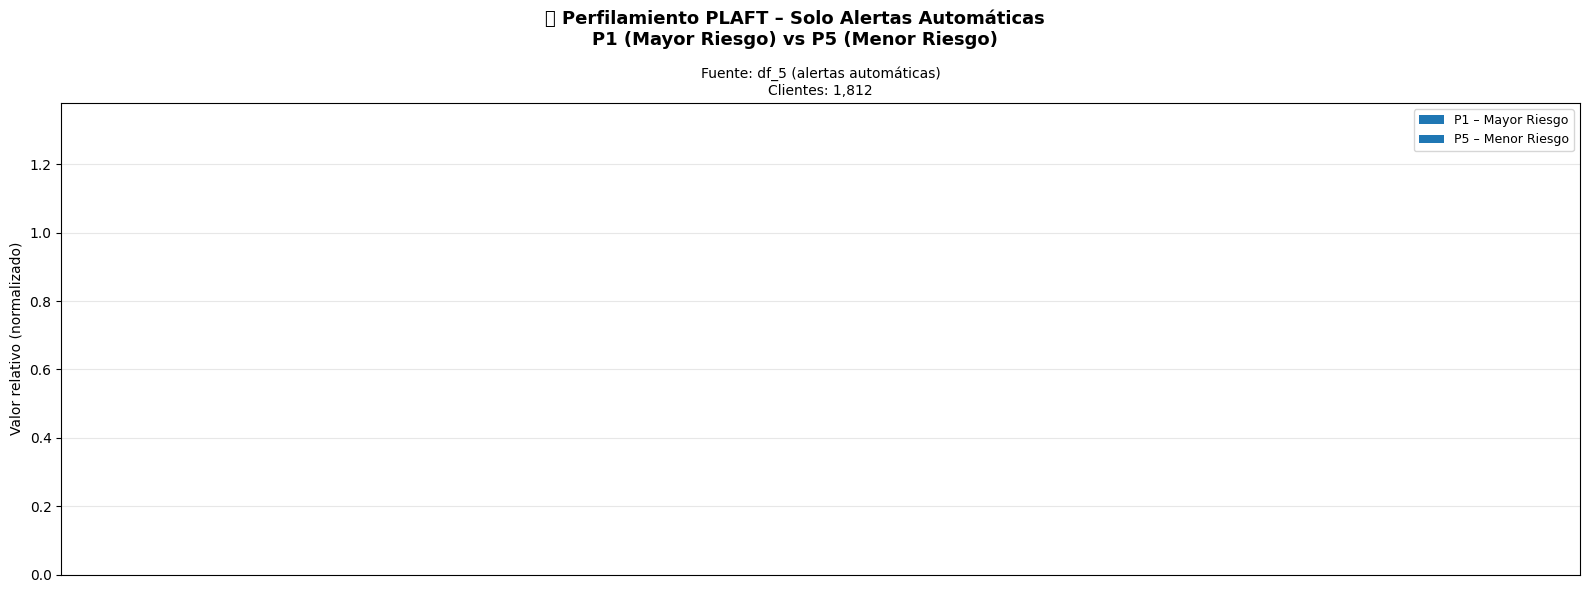

Fuente usada: df_5 (alertas automáticas)
Registros: 1,812
P1: 395 | P5: 261


In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ================================================================
# GRAFICO COMPARATIVO — SOLO ALERTAS AUTOMÁTICAS
# ================================================================

# 1) Fuente de datos: alertas automáticas
if 'df_5' in globals() and isinstance(df_5, pd.DataFrame):
    df_perfil_auto = df_5.copy()
    fuente = 'df_5 (alertas automáticas)'
else:
    df_perfil_auto = df_test_3.copy()
    if 'tipo_alerta_n2' in df_perfil_auto.columns:
        df_perfil_auto = df_perfil_auto[df_perfil_auto['tipo_alerta_n2'].eq('AUTOMATICA')].copy()
    fuente = 'df_test_3 filtrado por tipo_alerta_n2 == AUTOMATICA'

# 2) Asegurar columna de target si viene como target_m
if 'target' not in df_perfil_auto.columns and 'target_m' in df_perfil_auto.columns:
    df_perfil_auto['target'] = df_perfil_auto['target_m']

# 3) Quintiles: usar quintil_202508 si existe, si no usar qcut sobre prob
if 'quintil_202508' in df_perfil_auto.columns:
    df_perfil_auto['quintil'] = df_perfil_auto['quintil_202508'].astype(int)
else:
    df_perfil_auto['quintil'] = pd.qcut(df_perfil_auto['prob'], 5, labels=[5, 4, 3, 2, 1]).astype(int)

Q_MAP = {1: 'P1 – Alto', 2: 'P2', 3: 'P3', 4: 'P4', 5: 'P5 – Bajo'}
df_perfil_auto['grupo_score'] = df_perfil_auto['quintil'].map(Q_MAP)

# 4) Variables a graficar
VARS_PLOT = [
    ('imp_trx_abonosefect_12m', 'Depósitos\nEfectivo 12m'),
    ('imp_trx_cargostot_1m', 'Egresos\nTotales 1m'),
    ('monto_transferencias_soles', 'Transf.\nSoles mes'),
    ('fe_velocidad_rotacion', 'Velocidad\nRotación'),
    ('monto_total_dolares', 'Total\nDólares'),
    ('td_avg_monto_1h', 'Ráfaga TD\n1 hora'),
    ('concentracion_dia_max', 'Conc.\ndía máx.'),
    ('num_antiguedad', 'Antigüedad\n(meses)'),
    ('n_trx_efectivo', 'N° trx\nEfectivo'),
    ('monto_max_soles', 'Monto\nmáx. trx'),
]
VARS_PLOT = [(c, lbl) for c, lbl in VARS_PLOT if c in df_perfil_auto.columns]

p1_df = df_perfil_auto[df_perfil_auto['quintil'] == 1]
p5_df = df_perfil_auto[df_perfil_auto['quintil'] == 5]

p1_vals = [p1_df[c].median() for c, _ in VARS_PLOT]
p5_vals = [p5_df[c].median() for c, _ in VARS_PLOT]
labels = [lbl for _, lbl in VARS_PLOT]

maxv = [max(abs(a), abs(b), 1e-9) for a, b in zip(p1_vals, p5_vals)]
p1_norm = [a / m for a, m in zip(p1_vals, maxv)]
p5_norm = [b / m for b, m in zip(p5_vals, maxv)]

x = np.arange(len(labels))
ancho = 0.36

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('📊 Perfilamiento PLAFT – Solo Alertas Automáticas\nP1 (Mayor Riesgo) vs P5 (Menor Riesgo)',
             fontsize=13, fontweight='bold')

b1 = ax.bar(x - ancho/2, p1_norm, ancho, label='P1 – Mayor Riesgo', color='#E53935', alpha=0.85, zorder=3)
b2 = ax.bar(x + ancho/2, p5_norm, ancho, label='P5 – Menor Riesgo', color='#4CAF50', alpha=0.85, zorder=3)

for bar, val in zip(b1, p1_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=7, color='#7B0000')
for bar, val in zip(b2, p5_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=7, color='#1B5E20')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Valor relativo (normalizado)', fontsize=10)
ax.set_ylim(0, 1.38)
ax.grid(axis='y', alpha=0.3, zorder=1)
ax.legend(fontsize=9, loc='upper right')
ax.set_title(f'Fuente: {fuente}\nClientes: {len(df_perfil_auto):,}', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Fuente usada: {fuente}")
print(f"Registros: {len(df_perfil_auto):,}")
print(f"P1: {len(p1_df):,} | P5: {len(p5_df):,}")


In [75]:

import pandas as pd
import numpy as np
from IPython.display import display, HTML

# ================================================================
# TABLA COMPARATIVA — Top 20 Variables SHAP
# ■ "Todos los clientes"  : mediana universo completo (df_test_3)
# ■ P1 … P5              : mediana solo alertas automáticas
#                          (df_test_3 cruzado con df_5 por cuc_num+cod_mes,
#                           quintil asignado con cortes fijos de 202508)
# ■ "Patrón analista"    : descripción extraída de comentarios
# ================================================================

# ── 0. Crear df_alertas_features ─────────────────────────────────
# df_test_3 tiene todas las features del modelo
# df_5 tiene quintil_202508 y filtra alertas automáticas
# → cruzamos para tener features + quintil, solo alertas automáticas

_t3 = df_test_3.copy()
_t3['_cuc_str'] = pd.to_numeric(_t3['cuc_num'], errors='coerce').astype('Int64').astype(str)
_t3['_mes_str'] = pd.to_numeric(_t3['cod_mes'], errors='coerce').astype('Int64').astype(str)

_df5_keys = df_5[['cuc_num', 'cod_mes', 'quintil_202508']].copy()
_df5_keys['_cuc_str'] = _df5_keys['cuc_num'].astype(str).str.strip()
_df5_keys['_mes_str'] = _df5_keys['cod_mes'].astype(str).str.strip()

df_alertas_features = _t3.merge(
    _df5_keys[['_cuc_str', '_mes_str', 'quintil_202508']],
    on=['_cuc_str', '_mes_str'],
    how='inner'
).drop(columns=['_cuc_str', '_mes_str'])

print(f"✅ df_alertas_features: {len(df_alertas_features):,} registros")
print(f"   Distribución por quintil: {df_alertas_features['quintil_202508'].value_counts().sort_index().to_dict()}")

# ── 1. Selección de variables — Top 10 con mayor contraste P1/P5 y alineación analista ──
# (del Top 20 SHAP se seleccionan las 10 con P1>>P5 más claro y patrón analista más directo)
TOP10_VARS_SELEC = [
    'imp_trx_abonostot_3m',         # Depósitos 3m — ratio P1/P5 = 56x
    'imp_trx_abonosefect_12m',      # Efectivo anual — ratio 260x
    'imp_trx_cargosefe_12m',        # Egresos efectivo — ratio 85x
    'monto_transferencias_soles',   # Transferencias — ratio 87x
    'monto_debitos_soles',          # Egresos soles — ratio 48x
    'n_trx_mismo_cliente',          # Cuentas propias — ratio 17x
    'cnt_trx_cargostot_12m',        # N° egresos — ratio 13x
    'cnt_trx_abonostot_12m',        # N° depósitos — ratio 11x
    'monto_max_soles',              # Monto máximo — ratio 12x
    'fe_velocidad_rotacion',        # Intensidad fondos — ratio 10x
    'num_antiguedad',               # Antigüedad — clientes nuevos con alto volumen
]

top20      = df_shap.head(20).copy().reset_index(drop=True)
top20_vars = [v for v in TOP10_VARS_SELEC if v in df_shap['variable_original'].values]

# Nombre gerencial: df_shap primero, luego nombres_gerenciales_shap como fallback
nombre_map = {
    col: (top20.set_index('variable_original')['nombre_gerencial'].to_dict().get(col)
          or nombres_gerenciales_shap.get(col)
          or col)
    for col in top20_vars
}
shap_map = top20.set_index('variable_original')['shap_importancia'].to_dict()

# ── 2. Patrón del analista ────────────────────────────────────────
PATRON_ANALISTA = {
    'imp_trx_abonosefect_12m':    'Depósitos anuales en efectivo muy elevados vs. perfil e ingresos declarados',
    'fe_zscore_cargos':           'Egresos estadísticamente atípicos; analista verifica con actividad SUNAT',
    'cnt_trx_cargostot_12m':      'Alta frecuencia de egresos anuales sin correlato en ingresos formales',
    'flg_vrcn_abonos_5m_1m':      'Incremento repentino de depósitos; analista solicita origen de fondos',
    'imp_trx_cargosefe_12m':      'Egresos anuales en efectivo inconsistentes con actividad declarada',
    'concentracion_dia_max':      'Varias operaciones en el mismo día ("estructuración"); analista documenta',
    'fe_velocidad_rotacion':      'Fondos que entran y salen rápido ("paso de dinero"); analista pide sustento',
    'mto_dif_abn_crgsefe_6m':     'Gran brecha depósitos vs. egresos en efectivo; analista pide sustento de fondos',
    'ratio_debito_credito':       'Desbalance egresos/depósitos inconsistente con perfil declarado',
    'cnt_dif_abn_crgsefe_6m':     'Diferencia alta en cant. de operaciones efectivo (depósitos vs. egresos)',
    'rat_trx_mntabnsefetot_6m':   'Alta proporción de efectivo sobre total; analista evalúa SUNAT/SSFF',
    'monto_transferencias_soles': 'Transferencias de alto monto S/; analista verifica legitimidad de contraparte',
    'cnt_trx_abonostot_12m':      'Número de depósitos anuales inusualmente alto para el segmento Masivo',
    'td_avg_monto_1h':            'Ráfagas de alto monto en TD en 1 hora; posible atomización de operaciones',
    'flg_activo':                 'Cliente activo con comportamiento transaccional inconsistente con perfil',
    'num_antiguedad':             'Cliente reciente con alto volumen; analista solicita justificación de fondos',
    'n_trx_mismo_cliente':        'Traslados frecuentes entre cuentas propias para dispersar o acumular saldos',
    'monto_debitos_soles':        'Egresos de alto valor en S/; analista verifica destino (SUNARP, SSFF)',
    'monto_total_dolares':        'Operaciones en USD sin perfil internacional justificado (SUNAT / RRLL)',
    'fe_ratio_salidas_entradas':  'Ratio de salidas muy alto; analista verifica si contraparte tiene ROS activo',
    'imp_trx_cargostot_1m':       'Egresos del último mes muy elevados vs. meses anteriores; analista compara',
    'fe_ratio_efectivo_vs_total': 'Alta proporción de efectivo sobre total; posible evasión de trazabilidad',
    'monto_efectivo_soles':       'Monto mensual en efectivo muy superior al promedio del segmento',
    'n_trx_efectivo':             'Número de transacciones en efectivo inusualmente alto para el segmento',
    'monto_max_soles':            'Transacciones individuales de montos muy altos; analista verifica origen',
    'n_canales_distintos':        'Uso de múltiples canales para fragmentar o atomizar operaciones',
    'n_trx_app':                  'Alto volumen de operaciones por APP; posible atomización de fondos',
    'n_trx_pagos':                'Pagos frecuentes o de alto monto sin correlato con perfil declarado',
    'monto_promedio_dolares':     'Monto promedio en USD elevado para el segmento Masivo',
    'td_monto_total':             'Monto total TD muy alto; analista verifica actividad comercial formal',
    'imp_trx_abonostot_3m':      'Alto monto acumulado de depósitos en 3 meses; analista verifica origen de fondos',
}

# ── 3. Variables en porcentaje ────────────────────────────────────
IS_PCT = {
    'flg_activo', 'flg_vrcn_abonos_5m_1m',
    'fe_ratio_efectivo_vs_total', 'rat_trx_mntabnsefetot_6m',
    'fe_ratio_salidas_entradas', 'ratio_debito_credito',
}

def _fmt_comp(val, as_pct=False):
    if pd.isna(val):
        return '–'
    if abs(val) < 1e-9:          # exactamente cero
        return '0.0%' if as_pct else '0'
    if as_pct:
        return f'{val * 100:.1f}%'
    if abs(val) >= 1_000_000:
        return f'{val / 1_000_000:.2f}M'
    if abs(val) >= 1_000:
        return f'{val:,.0f}'
    if abs(val) >= 10:
        return f'{val:,.1f}'
    if abs(val) >= 0.001:
        return f'{val:.3f}'
    return f'{val:.5f}'

def _stat_comp(serie, as_pct=False):
    """
    Para variables con muchos ceros usa la media (promedio),
    para el resto usa la mediana.
    Devuelve (valor, sufijo) donde sufijo indica el estadístico usado.
    """
    s = serie.dropna()
    if len(s) == 0:
        return np.nan, ''
    pct_cero = (s == 0).mean()
    if pct_cero > 0.50:          # >50% son ceros → media más informativa
        return s.mean(), ' ᵃ'   # superíndice 'a' = promedio
    return s.median(), ''        # mediana estándar

# ── 4. Construir filas ────────────────────────────────────────────
filas_comp = []
for col in top20_vars:
    nombre = nombre_map.get(col, col)
    shap_v = shap_map.get(col, 0)
    as_pct = col in IS_PCT

    # Todos los clientes — universo completo df_test_3
    if col in df_test_3.columns:
        val_todos, suf_todos = _stat_comp(df_test_3[col], as_pct)
    else:
        val_todos, suf_todos = np.nan, ''

    fila = {
        'Variable (Top 20 SHAP)': nombre,
        'SHAP': f'{shap_v:.4f}',
        'Todos los clientes': _fmt_comp(val_todos, as_pct) + suf_todos,
    }

    # P1–P5 — solo alertas automáticas con features (df_alertas_features)
    for q in [1, 2, 3, 4, 5]:
        if col in df_alertas_features.columns:
            sub = df_alertas_features[df_alertas_features['quintil_202508'] == q][col]
            val_q, suf_q = _stat_comp(sub, as_pct)
        else:
            val_q, suf_q = np.nan, ''
        fila[f'P{q}'] = _fmt_comp(val_q, as_pct) + suf_q

    fila['Patrón observado por analista'] = PATRON_ANALISTA.get(col, '—')
    filas_comp.append(fila)

df_comparativa = pd.DataFrame(filas_comp)

# ── 5. Colores por columna ────────────────────────────────────────
HCOLORS = {
    'Variable (Top 20 SHAP)': '#1a2e5a',
    'SHAP':                   '#37474F',
    'Todos los clientes':     '#1565C0',
    'P1': '#B71C1C', 'P2': '#8D4500', 'P3': '#1a2e5a', 'P4': '#2E7D32', 'P5': '#1B5E20',
    'Patrón observado por analista': '#4A148C',
}

def _render_comp_nb(df):
    cols = df.columns.tolist()
    ths = []
    for c in cols:
        bg = HCOLORS.get(c, '#1a2e5a')
        ths.append(
            f'<th style="background:{bg};color:white;padding:8px 10px;'
            f'font-size:11px;white-space:nowrap">{c}</th>'
        )
    rows_html = []
    for i, (_, row) in enumerate(df.iterrows()):
        bg_row = '#f7f9fc' if i % 2 == 0 else '#ffffff'
        tds = []
        for c, v in zip(cols, row.values):
            if c == 'P1':
                s = 'background:#FFD0D0;color:#7B0000;font-weight:700;text-align:center'
            elif c == 'P5':
                s = 'background:#D6FFD6;color:#1B5E20;font-weight:700;text-align:center'
            elif c in ('P2', 'P3', 'P4'):
                s = 'text-align:center'
            elif c == 'Todos los clientes':
                s = 'background:#EEF2FA;text-align:center;font-weight:600;color:#1a2e5a'
            elif 'Patrón' in c:
                s = 'text-align:left;font-size:10px;color:#555;font-style:italic;min-width:210px'
            elif c == 'SHAP':
                s = 'text-align:center;color:#795548;font-family:monospace;font-size:10px'
            else:
                s = 'text-align:left;font-weight:600;min-width:200px'
            tds.append(
                f'<td style="padding:5px 8px;border-bottom:1px solid #e8eaf0;{s}">{v}</td>'
            )
        rows_html.append(f'<tr style="background:{bg_row}">{"".join(tds)}</tr>')

    nota = (
        '<div style="background:#f0f4ff;border-left:4px solid #2d5fa6;padding:10px 14px;'
        'margin-bottom:12px;border-radius:0 6px 6px 0;font-size:11px">'
        '<b>Lectura:</b>&nbsp;'
        '<b>Todos los clientes</b>: estadístico del universo completo (df_test_3) &nbsp;·&nbsp; '
        '<b>P1–P5</b>: por quintil, <u>solo alertas automáticas</u>, cortes fijos 202508 &nbsp;·&nbsp; '
        '<b style="color:#B71C1C">P1 = mayor score / mayor riesgo</b> &nbsp;·&nbsp; '
        '<b style="color:#1B5E20">P5 = menor riesgo</b>'
        '<br><span style="color:#666">'
        '&nbsp;·&nbsp; Se usa <b>mediana</b> cuando &le;50% son cero; '
        '<b>promedio</b> (marcado con <sup>a</sup>) cuando &gt;50% son cero — '
        'ej. la mayoría de clientes no hace depósitos en efectivo → mediana=0, '
        'el promedio muestra cuánto mueven los que sí lo hacen.'
        '</span>'
        '</div>'
    )
    tbl = (
        '<div style="overflow-x:auto">'
        '<table style="width:100%;border-collapse:collapse;font-family:Arial,sans-serif;font-size:11px">'
        f'<thead><tr>{"".join(ths)}</tr></thead>'
        f'<tbody>{"".join(rows_html)}</tbody>'
        '</table></div>'
    )
    return nota + tbl

# ── 6. Mostrar ───────────────────────────────────────────────────
print("═" * 90)
print("  TOP 10 VARIABLES — Mayor contraste P1/P5 y alineación con el analista PLAFT")
print("  P1 = mayor score (mayor riesgo)  |  P5 = menor score (menor riesgo)")
print("═" * 90)
display(HTML(_render_comp_nb(df_comparativa)))
print(f"\n✅ df_comparativa: {len(df_comparativa)} variables × {len(df_comparativa.columns)} columnas")


✅ df_alertas_features: 2,176 registros
   Distribución por quintil: {1: 491, 2: 558, 3: 406, 4: 403, 5: 318}
══════════════════════════════════════════════════════════════════════════════════════════
  TOP 10 VARIABLES — Mayor contraste P1/P5 y alineación con el analista PLAFT
  P1 = mayor score (mayor riesgo)  |  P5 = menor score (menor riesgo)
══════════════════════════════════════════════════════════════════════════════════════════
══════════════════════════════════════════════════════════════════════════════════════════
  TOP 10 VARIABLES — Mayor contraste P1/P5 y alineación con el analista PLAFT
  P1 = mayor score (mayor riesgo)  |  P5 = menor score (menor riesgo)
══════════════════════════════════════════════════════════════════════════════════════════


Variable (Top 20 SHAP),SHAP,Todos los clientes,P1,P2,P3,P4,P5,Patrón observado por analista
Monto total de depósitos (últimos 3 meses),0.4895,"4,017","988,991","625,051","468,955","298,894","17,708",Alto monto acumulado de depósitos en 3 meses; analista verifica origen de fondos
Monto total depositado en efectivo (12m),0.4861,"6,630 ᵃ","266,755","96,750","65,420","26,439","1,026",Depósitos anuales en efectivo muy elevados vs. perfil e ingresos declarados
Monto anual egresos en efectivo,0.3616,540.0,"212,500","89,208","50,028","17,794","2,500",Egresos anuales en efectivo inconsistentes con actividad declarada
Monto transferencias en soles,0.1007,232.5,"68,539","28,903","11,781","3,389",786.8,Transferencias de alto monto S/; analista verifica legitimidad de contraparte
Monto total egresos en soles,0.0885,860.0,"92,465","61,676","20,667","10,346","1,920","Egresos de alto valor en S/; analista verifica destino (SUNARP, SSFF)"
Transferencias entre cuentas propias,0.1265,1.000,17.0,9.000,7.000,2.000,1.000,Traslados frecuentes entre cuentas propias para dispersar o acumular saldos
Número de egresos (12m),0.2689,96.0,"1,082",916.0,512.5,331.0,83.0,Alta frecuencia de egresos anuales sin correlato en ingresos formales
Número de depósitos totales (12m),0.1555,34.0,320.0,199.0,117.5,77.0,28.0,Número de depósitos anuales inusualmente alto para el segmento Masivo
Monto máximo de transacción,0.1238,500.0,"19,361","14,765","7,594","6,000","1,637",Transacciones individuales de montos muy altos; analista verifica origen
Intensidad de uso de fondos,0.1567,1.756,7.273,2.381,0.403,0.260,0.712,"Fondos que entran y salen rápido (""paso de dinero""); analista pide sustento"



✅ df_comparativa: 11 variables × 9 columnas


## Análisis de Comentarios de Analistas PLAFT
### ¿El modelo captura lo que el analista observa?

Se analizan los comentarios de calificación de analistas PLAFT para identificar:
1. **Qué señales observan** los analistas al calificar un cliente como "Con Riesgo"
2. **Cuántas de esas señales** están cubiertas por las variables del modelo
3. **Qué brecha existe**: señales que usa el analista pero el modelo no captura


📋 Muestra de comentarios: 30 registros | Periodos: [202501, 202502, 202503, 202504, 202505, 202506, 202507]
   Calificaciones: {'CON RIESGO': 30}

════════════════════════════════════════════════════════════════════════════════
  ALINEACIÓN: Lo que el analista observa vs. lo que el modelo captura
  Verde = señal cubierta por alguna variable del modelo
  Rojo  = señal que el analista usa pero NO está en el modelo
════════════════════════════════════════════════════════════════════════════════



Señal observada por analista,En modelo,Variable(s) del modelo,Menciones,% comentarios
🕐 Antigüedad del cliente,✅ Sí,num_antiguedad,30,100%
⚠️ Deuda en el sistema financiero (SSFF),❌ No,— No disponible en features del modelo,30,100%
⚠️ RRLL (Representante Legal),❌ No,— No disponible en features del modelo,30,100%
💵 Depósitos / Abonos en efectivo,✅ Sí,"imp_trx_abonosefect_12m, cnt_trx_abonosefect_12m",29,97%
⚠️ PEP — el propio cliente es Persona Expuesta Políticamente,❌ No,"— flg_pep (del propio cliente, no en modelo final)",27,90%
📤 Retiros / Cargos en efectivo,✅ Sí,"imp_trx_cargosefe_12m, imp_trx_cargostot_1m",26,87%
🔄 Transferencias,✅ Sí,"monto_transferencias_soles, n_trx_mismo_cliente",24,80%
⚠️ Historial ROS / alertas previas — del propio cliente,❌ No,cnt_ros_hist / flg_alerta_12m del propio cliente (no en modelo final),24,80%
💳 Tarjeta débito / crédito,✅ Sí,"td_avg_monto_1h, td_monto_total, tc_total_monto_mes",24,80%
💱 Operaciones en dólares / exterior,✅ Sí,"monto_total_dolares, monto_promedio_dolares",22,73%


C:\Users\b46637\AppData\Local\Temp\ipykernel_17428\1899906300.py:229: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\b46637\AppData\Local\Temp\ipykernel_17428\1899906300.py:229: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\b46637\AppData\Local\Temp\ipykernel_17428\1899906300.py:229: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\b46637\AppData\Local\Temp\ipykernel_17428\1899906300.py:230: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('analisis_comentarios_analistas.png', dpi=150, bbox_inches='tight')
C:\Users\b46637\AppData\Local\Temp\ipykernel_17428\1899906300.py:230: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('analisis_comentarios_analistas.png', dpi=150, bbox_inches='tight')
C:\Users\b46637\AppDa

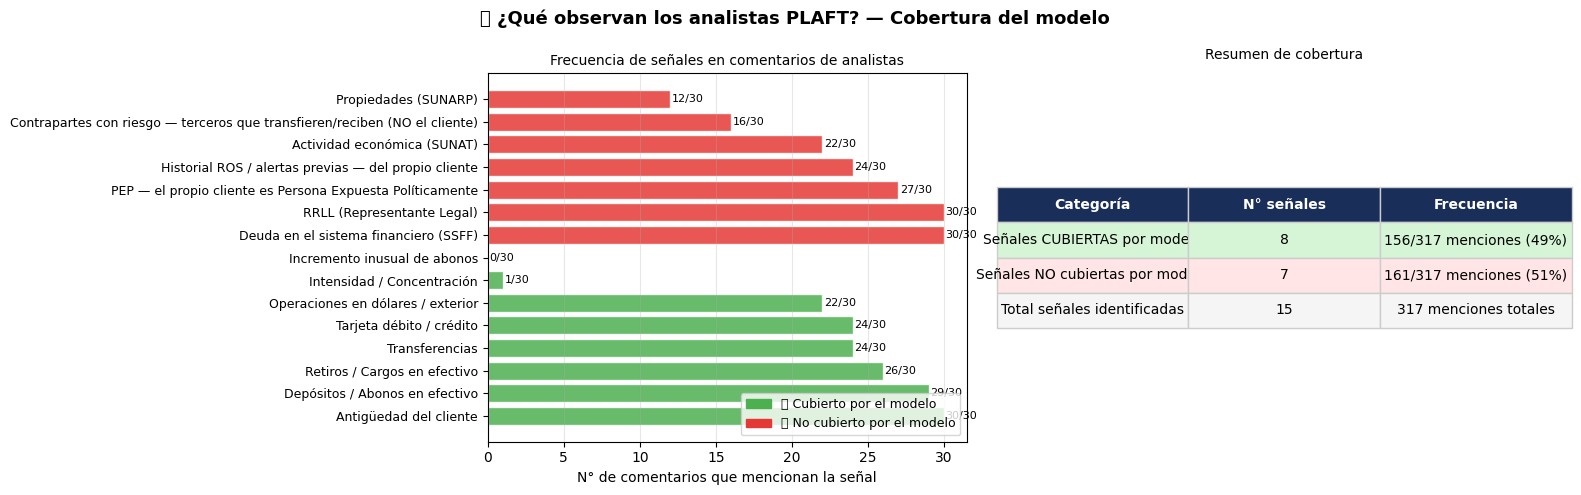


════════════════════════════════════════════════════════════════════════════════
  EXTRACTOS REPRESENTATIVOS DE COMENTARIOS
════════════════════════════════════════════════════════════════════════════════

  【💵 Depósitos / Abonos en efectivo】
    → ...en el periodo revisado (202407 a 202501), se observa la siguiente operativa:     ingresos:   - deposito-efe-sin-trj por pen 7,000...
    → ...en el periodo revisado (202407 a 202501), se observa la siguiente operativa:   ingresos:   - transferencia por usd 392,355...

  【📤 Retiros / Cargos en efectivo】
    → ...egresos:   - trans-ordinaria por pen 14,160...
    → ...egresos:   - retiros por usd 387,654...

  【🔄 Transferencias】
    → ...en el periodo revisado (202407 a 202501), se observa la siguiente operativa:   ingresos:   - transferencia por usd 392,355...
    → ...en el periodo revisado (202407 a 202501), se observa la siguiente operativa:     ingresos:   - transferencias interbancarias por pen 2,059,518...

  【⚡ Intensidad / Concent

In [76]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
from collections import Counter
from IPython.display import display, HTML

# ================================================================
# ANÁLISIS DE COMENTARIOS DE ANALISTAS PLAFT
# ¿Qué variables observan los analistas? ¿Coinciden con el modelo?
# ================================================================

df_coment = pd.read_csv(
    r'C:\Users\b46637\OneDrive - Interbank\PLAFT\Masivo\Desarrollo\MUESTRA_COMENTARIOS_CALIFICACION_MASIVO.csv',
    sep=';', encoding='utf-8', on_bad_lines='skip'
)
df_coment.columns = df_coment.columns.str.strip().str.upper()
df_coment['COMENTARIO'] = df_coment['COMENTARIO'].fillna('').astype(str).str.lower()

print(f"📋 Muestra de comentarios: {len(df_coment)} registros | Periodos: {sorted(df_coment['PERIODO_ALERTA'].unique().tolist())}")
print(f"   Calificaciones: {df_coment['CALIFICACION_MONITOREO'].value_counts().to_dict()}")

# ================================================================
# 1. DICCIONARIO DE SEÑALES — qué busca el analista
# ================================================================
SEÑALES = {
    # ── SEÑALES CUBIERTAS POR EL MODELO ──────────────────────────
    '💵 Depósitos / Abonos en efectivo': {
        'keywords': ['depósito', 'deposito', 'abono', 'ingreso', 'efectivo', 'cash'],
        'en_modelo': True,
        'variables_modelo': 'imp_trx_abonosefect_12m, cnt_trx_abonosefect_12m',
    },
    '📤 Retiros / Cargos en efectivo': {
        'keywords': ['retiro', 'cargo', 'egreso', 'salida', 'extracción', 'extraccion'],
        'en_modelo': True,
        'variables_modelo': 'imp_trx_cargosefe_12m, imp_trx_cargostot_1m',
    },
    '🔄 Transferencias': {
        'keywords': ['transferencia', 'transfer', 'envío', 'envio', 'remesa', 'yape', 'plin', 'interbancaria'],
        'en_modelo': True,
        'variables_modelo': 'monto_transferencias_soles, n_trx_mismo_cliente',
    },
    '⚡ Intensidad / Concentración': {
        'keywords': ['concentr', 'frecuent', 'intenso', 'intensidad', 'acumulado', 'período corto', 'periodo corto', 'misma fecha', 'mismo día'],
        'en_modelo': True,
        'variables_modelo': 'concentracion_dia_max, fe_velocidad_rotacion',
    },
    '📈 Incremento inusual de abonos': {
        'keywords': ['increment', 'aumento', 'variación', 'variacion', 'inusual', 'inusualmente', 'elevado', 'atípic', 'atipic'],
        'en_modelo': True,
        'variables_modelo': 'flg_vrcn_abonos_5m_1m, fe_zscore_cargos',
    },
    '💱 Operaciones en dólares / exterior': {
        'keywords': ['dólar', 'dolar', 'usd', 'exterior', 'extran', 'internacional'],
        'en_modelo': True,
        'variables_modelo': 'monto_total_dolares, monto_promedio_dolares',
    },
    '🕐 Antigüedad del cliente': {
        'keywords': ['vinculado', 'antigüedad', 'antiguedad', 'años en el banco', 'tiempo en'],
        'en_modelo': True,
        'variables_modelo': 'num_antiguedad',
    },
    '💳 Tarjeta débito / crédito': {
        'keywords': ['tarjeta', 'débito', 'debito', 'crédito', 'credito', 'pos', 'consumo'],
        'en_modelo': True,
        'variables_modelo': 'td_avg_monto_1h, td_monto_total, tc_total_monto_mes',
    },

    # ── SEÑALES NO CUBIERTAS POR EL MODELO ───────────────────────
    '⚠️ PEP — el propio cliente es Persona Expuesta Políticamente': {
        'keywords': ['pep', 'politicamente expuesta', 'políticamente expuesta'],
        'en_modelo': False,
        'variables_modelo': '— flg_pep (del propio cliente, no en modelo final)',
    },
    '⚠️ RRLL (Representante Legal)': {
        'keywords': ['rrll', 'representante legal', 'socio', 'gerente', 'director'],
        'en_modelo': False,
        'variables_modelo': '— No disponible en features del modelo',
    },
    '⚠️ Actividad económica (SUNAT)': {
        'keywords': ['sunat', 'actividad económica', 'actividad economica', 'ciiu', 'ruc'],
        'en_modelo': False,
        'variables_modelo': '— No disponible en features del modelo',
    },
    '⚠️ Propiedades (SUNARP)': {
        'keywords': ['sunarp', 'propiedad', 'inmueble', 'registral', 'zona registral'],
        'en_modelo': False,
        'variables_modelo': '— No disponible en features del modelo',
    },
    '⚠️ Historial ROS / alertas previas — del propio cliente': {
        'keywords': ['ros', 'reporte de operación', 'reporte de operacion', 'alerta previa', 'caso previo', 'investigación', 'investigacion'],
        'en_modelo': False,
        'variables_modelo': 'cnt_ros_hist / flg_alerta_12m del propio cliente (no en modelo final)',
    },
    '⚠️ Deuda en el sistema financiero (SSFF)': {
        'keywords': ['ssff', 'sistema financiero', 'deuda', 'endeudamiento', 'crédito bancario'],
        'en_modelo': False,
        'variables_modelo': '— No disponible en features del modelo',
    },
    '⚠️ Contrapartes con riesgo — terceros que transfieren/reciben (NO el cliente)': {
        'keywords': ['contraparte', 'empresa vinculada', 'empresa relacionada', 'tercero'],
        'en_modelo': False,
        'variables_modelo': 'mto_cp_tot_ing_ros / flg_t1cp_rosing_12m (no en modelo final)',
    },
}

# ================================================================
# 2. CONTEO DE MENCIONES POR SEÑAL
# ================================================================
resultados_señales = []
menciones_por_comentario = []

for idx, row in df_coment.iterrows():
    texto = row['COMENTARIO']
    fila_c = {'periodo': row['PERIODO_ALERTA']}
    for señal, cfg in SEÑALES.items():
        encontrado = any(kw in texto for kw in cfg['keywords'])
        fila_c[señal] = int(encontrado)
    menciones_por_comentario.append(fila_c)

df_menciones = pd.DataFrame(menciones_por_comentario)

for señal, cfg in SEÑALES.items():
    n = df_menciones[señal].sum()
    pct = n / len(df_coment) * 100
    resultados_señales.append({
        'Señal observada por analista': señal,
        'En modelo': '✅ Sí' if cfg['en_modelo'] else '❌ No',
        'Variable(s) del modelo': cfg['variables_modelo'],
        'Menciones': n,
        '% comentarios': f'{pct:.0f}%',
    })

df_señales = pd.DataFrame(resultados_señales).sort_values('Menciones', ascending=False)

# ================================================================
# 3. TABLA RESUMEN — alineación analista vs. modelo
# ================================================================
def _color_señal(row):
    color = '#D6F5D6' if '✅' in row['En modelo'] else '#FFE5E5'
    return [f'background-color:{color}'] * len(row)

tabla_señales = (
    df_señales.style
    .apply(_color_señal, axis=1)
    .set_table_styles([
        {'selector': 'thead tr th',
         'props': [('background-color', '#1a2e5a'), ('color', 'white'),
                   ('font-size', '11px'), ('padding', '6px 10px')]},
        {'selector': 'td, th',
         'props': [('font-size', '11px'), ('padding', '4px 8px'),
                   ('border', '1px solid #ddd')]},
        {'selector': 'td:nth-child(3)',
         'props': [('text-align', 'left'), ('font-family', 'monospace'), ('font-size', '10px')]},
    ])
    .hide(axis='index')
    .set_caption('🔍 Señales observadas por analistas PLAFT — Cobertura del modelo')
)

print("\n" + "═" * 80)
print("  ALINEACIÓN: Lo que el analista observa vs. lo que el modelo captura")
print("  Verde = señal cubierta por alguna variable del modelo")
print("  Rojo  = señal que el analista usa pero NO está en el modelo")
print("═" * 80 + "\n")
display(tabla_señales)

# ================================================================
# 4. GRÁFICO — señales cubiertas vs. no cubiertas
# ================================================================
en_modelo = df_señales[df_señales['En modelo'] == '✅ Sí'].copy()
no_modelo = df_señales[df_señales['En modelo'] == '❌ No'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('📊 ¿Qué observan los analistas PLAFT? — Cobertura del modelo',
             fontsize=13, fontweight='bold')

all_data  = pd.concat([en_modelo, no_modelo])
colores   = ['#4CAF50' if '✅' in v else '#E53935' for v in all_data['En modelo']]
nombres   = [s.split(' ', 1)[1] if len(s) > 3 else s for s in all_data['Señal observada por analista']]
menciones = all_data['Menciones'].values

ax = axes[0]
bars = ax.barh(range(len(nombres)), menciones, color=colores, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(nombres)))
ax.set_yticklabels(nombres, fontsize=9)
ax.set_xlabel('N° de comentarios que mencionan la señal')
ax.set_title('Frecuencia de señales en comentarios de analistas', fontsize=10)
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, menciones):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val}/{len(df_coment)}', va='center', fontsize=8)

patch_si = mpatches.Patch(color='#4CAF50', label='✅ Cubierto por el modelo')
patch_no = mpatches.Patch(color='#E53935', label='❌ No cubierto por el modelo')
ax.legend(handles=[patch_si, patch_no], fontsize=9, loc='lower right')

n_si  = len(en_modelo)
n_no  = len(no_modelo)
m_si  = en_modelo['Menciones'].sum()
m_no  = no_modelo['Menciones'].sum()
total = m_si + m_no

ax2 = axes[1]
ax2.axis('off')
resumen_txt = [
    ['Señales CUBIERTAS por modelo',    f'{n_si}',    f'{m_si}/{total} menciones ({m_si/total*100:.0f}%)'],
    ['Señales NO cubiertas por modelo', f'{n_no}',    f'{m_no}/{total} menciones ({m_no/total*100:.0f}%)'],
    ['Total señales identificadas',     f'{n_si+n_no}', f'{total} menciones totales'],
]
tbl = ax2.table(cellText=resumen_txt, colLabels=['Categoría', 'N° señales', 'Frecuencia'],
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.2)
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#ccc')
    if row == 0:
        cell.set_facecolor('#1a2e5a')
        cell.set_text_props(color='white', fontweight='bold')
    elif row == 1:
        cell.set_facecolor('#D6F5D6')
    elif row == 2:
        cell.set_facecolor('#FFE5E5')
    else:
        cell.set_facecolor('#F5F5F5')
ax2.set_title('Resumen de cobertura', fontsize=10, pad=10)

plt.tight_layout()
plt.savefig('analisis_comentarios_analistas.png', dpi=150, bbox_inches='tight')
plt.show()

# ================================================================
# 5. EXTRACTOS REPRESENTATIVOS por señal
# ================================================================
print("\n" + "═" * 80)
print("  EXTRACTOS REPRESENTATIVOS DE COMENTARIOS")
print("═" * 80)

# Claves deben coincidir EXACTAMENTE con las del dict SEÑALES
SEÑALES_MOSTRAR = [
    '💵 Depósitos / Abonos en efectivo',
    '📤 Retiros / Cargos en efectivo',
    '🔄 Transferencias',
    '⚡ Intensidad / Concentración',
    '⚠️ Actividad económica (SUNAT)',
    '⚠️ Historial ROS / alertas previas — del propio cliente',
]

for señal in SEÑALES_MOSTRAR:
    cfg = SEÑALES[señal]
    print(f"\n  【{señal}】")
    encontrados = 0
    for _, row in df_coment.iterrows():
        texto_orig = row['COMENTARIO']
        if any(kw in texto_orig for kw in cfg['keywords']):
            oraciones = re.split(r'[.;]', texto_orig)
            for oracion in oraciones:
                if any(kw in oracion for kw in cfg['keywords']):
                    print(f"    → ...{oracion.strip()[:180]}...")
                    encontrados += 1
                    break
        if encontrados >= 2:
            break
    if encontrados == 0:
        print("    (sin extractos con estas palabras clave)")

# ================================================================
# 6. CONCLUSIÓN AUTOMÁTICA
# ================================================================
print("\n" + "═" * 80)
print("  CONCLUSIÓN: ALINEACIÓN MODELO vs. ANALISTA")
print("═" * 80)

pct_cub    = m_si / total * 100
señales_gap = no_modelo[no_modelo['Menciones'] > 0]['Señal observada por analista'].tolist()

print(f"""
  📌 El modelo captura señales presentes en el {pct_cub:.0f}% de las menciones de analistas.

  ✅ SEÑALES DEL MODELO ALINEADAS con el análisis humano:
     • Movimientos en efectivo (depósitos + retiros) → variables más mencionadas
     • Transferencias (monto y frecuencia)
     • Intensidad / concentración de operaciones
     • Antigüedad del cliente
     • Incrementos inusuales (z-score de cargos, flag de variación)

  ⚠️  SEÑALES QUE USA EL ANALISTA pero NO están en el modelo:""")
for s in señales_gap:
    n = df_señales[df_señales['Señal observada por analista'] == s]['Menciones'].values[0]
    print(f"     – {s}  ({n}/{len(df_coment)} comentarios)")

print(f"""
  💡 INTERPRETACIÓN:
     El modelo cubre bien el COMPORTAMIENTO TRANSACCIONAL del cliente.
     El analista complementa con CONTEXTO EXTERNO (SUNAT, SUNARP, SSFF, RRLL)
     que no está en las features pero ayuda a confirmar o descartar el riesgo.
     Esto sugiere que el modelo es un buen primer filtro y el analista
     agrega inteligencia contextual que el modelo no puede capturar.
""")


In [77]:

import base64, os, datetime, pandas as pd, numpy as np
from IPython.display import display, HTML

# ================================================================
# GENERADOR DE INFORME HTML — PLAFT Masivo PN
# ================================================================
FECHA_HOY   = datetime.date.today().strftime('%d/%m/%Y')
MODELO_ID   = 'hpo-plaft-pn-masivo-260701-1603-042-a270185f'
OUTPUT_HTML = r'C:\Users\b46637\OneDrive - Interbank\PLAFT\Masivo\Desarrollo\informe_plaft_masivo.html'

def _img_b64(path):
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return base64.b64encode(f.read()).decode()
    return None

def _df_to_html(df, id_tabla=''):
    return df.to_html(index=False, border=0, classes=f'tabla {id_tabla}',
                      escape=False, na_rep='—')

# ── Imágenes embebidas ────────────────────────────────────────────
img_perfil   = _img_b64('perfilamiento_quintiles.png')
img_analista = _img_b64('analisis_comentarios_analistas.png')

def _img_tag(b64, alt='', width='100%'):
    if b64:
        return f'<img src="data:image/png;base64,{b64}" alt="{alt}" style="width:{width};border-radius:6px;box-shadow:0 2px 8px rgba(0,0,0,.15);">'
    return f'<p class="aviso">⚠ Imagen no encontrada. Ejecute las celdas anteriores primero.</p>'

# ── Tabla de quintiles por mes ────────────────────────────────────
resumen_q_fmt = resumen_q.copy()
resumen_q_fmt['efectividad']  = (resumen_q_fmt['efectividad']  * 100).map('{:.2f}%'.format)
resumen_q_fmt['prob_min']     = resumen_q_fmt['prob_min'].map('{:.4f}'.format)
resumen_q_fmt['prob_max']     = resumen_q_fmt['prob_max'].map('{:.4f}'.format)
resumen_q_fmt['cantidad']     = resumen_q_fmt['cantidad'].map('{:,.0f}'.format)
resumen_q_fmt['casos_riesgo'] = resumen_q_fmt['casos_riesgo'].map('{:,.0f}'.format)
resumen_q_fmt.columns = ['Mes', 'Quintil', 'Clientes', 'Con Riesgo', 'Efectividad', 'Score Mín.', 'Score Máx.']

df_tabla_html   = df_tabla.copy()
df_señales_html = df_señales[['Señal observada por analista', 'En modelo',
                               'Variable(s) del modelo', 'Menciones', '% comentarios']].copy()

try:
    p1_efect = resumen_q[resumen_q['quintil_202508'] == 1]['efectividad'].mean() * 100
    p1_label = f'{p1_efect:.2f}%'
except Exception:
    p1_label = 'N/D'

n_total_clientes = f'{len(df_perfil):,}'
score_p1_med     = f'{df_perfil[df_perfil["quintil"]==1]["prob"].median():.4f}'
score_p5_med     = f'{df_perfil[df_perfil["quintil"]==5]["prob"].median():.4f}'
n_variables_mod  = str(len(nombres_gerenciales_shap))
n_señales_cub    = str(df_señales[df_señales['En modelo']=='✅ Sí']['Menciones'].sum())
n_señales_tot    = str(df_señales['Menciones'].sum())

# ================================================================
# CSS
# ================================================================
CSS = """
*{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Segoe UI',Arial,sans-serif;background:#f4f6fb;color:#222;font-size:13px}
header{background:linear-gradient(135deg,#1a2e5a 0%,#2d5fa6 100%);color:#fff;padding:28px 40px}
header h1{font-size:22px;font-weight:700;letter-spacing:.5px}
header p{font-size:12px;opacity:.85;margin-top:6px}
.badges{display:flex;gap:10px;margin-top:14px;flex-wrap:wrap}
.badge{background:rgba(255,255,255,.15);border:1px solid rgba(255,255,255,.3);
       border-radius:20px;padding:4px 12px;font-size:11px}
main{max-width:1300px;margin:0 auto;padding:24px 20px}
.seccion{background:#fff;border-radius:10px;box-shadow:0 2px 10px rgba(0,0,0,.07);
         margin-bottom:24px;overflow:hidden}
.sec-header{background:#1a2e5a;color:#fff;padding:12px 20px;
            font-size:13px;font-weight:600;letter-spacing:.3px}
.sec-body{padding:18px 20px}
.kpis{display:grid;grid-template-columns:repeat(auto-fit,minmax(160px,1fr));gap:12px;margin-bottom:20px}
.kpi{background:linear-gradient(135deg,#f0f4ff,#e8edfa);border-radius:8px;
     padding:14px 16px;border-left:4px solid #2d5fa6;text-align:center}
.kpi .val{font-size:22px;font-weight:700;color:#1a2e5a}
.kpi .lbl{font-size:10px;color:#666;margin-top:4px;text-transform:uppercase;letter-spacing:.4px}
.kpi.rojo{border-left-color:#c62828;background:linear-gradient(135deg,#fff0f0,#ffe5e5)}
.kpi.rojo .val{color:#c62828}
.kpi.verde{border-left-color:#2e7d32;background:linear-gradient(135deg,#f0fff0,#e5ffe5)}
.kpi.verde .val{color:#2e7d32}
table.tabla{width:100%;border-collapse:collapse;font-size:11.5px}
table.tabla thead tr{background:#1a2e5a;color:#fff}
table.tabla thead th{padding:8px 10px;text-align:center;font-weight:600;white-space:nowrap}
table.tabla tbody tr:nth-child(even){background:#f7f9fc}
table.tabla tbody tr:hover{background:#eef2fb}
table.tabla td{padding:6px 10px;border-bottom:1px solid #e5e8ef;text-align:center}
table.tabla td:first-child{text-align:left}
.q1{background:#FFD0D0!important;color:#7B0000;font-weight:700}
.q5{background:#D6FFD6!important;color:#1B5E20;font-weight:700}
.cub{background:#D6F5D6!important}
.nocub{background:#FFE5E5!important}
.grid2{display:grid;grid-template-columns:1fr 1fr;gap:20px}
.nota{font-size:10.5px;color:#888;font-style:italic;margin-top:10px;padding:8px 12px;
      background:#fafafa;border-left:3px solid #ccc;border-radius:0 4px 4px 0}
.aviso{color:#c62828;font-size:11px;padding:10px;background:#fff0f0;border-radius:6px}
.gap-item{padding:8px 12px;background:#fff5f5;border-left:3px solid #e53935;
          border-radius:0 6px 6px 0;margin:4px 0;font-size:12px}
.ok-item{padding:8px 12px;background:#f5fff5;border-left:3px solid #4caf50;
         border-radius:0 6px 6px 0;margin:4px 0;font-size:12px}
.col2{display:grid;grid-template-columns:1fr 1fr;gap:16px}
footer{text-align:center;padding:16px;font-size:10px;color:#aaa;
       border-top:1px solid #e5e5e5;margin-top:10px}
@media(max-width:700px){.grid2,.col2{grid-template-columns:1fr}}
"""

# ================================================================
# HELPERS DE TABLA
# ================================================================
def _fila_quintiles(df_html):
    filas = []
    for _, row in df_html.iterrows():
        q = str(row.get('Quintil', ''))
        cls = 'q1' if q == '1' else ('q5' if q == '5' else '')
        celdas = ''.join(f'<td class="{cls}">{v}</td>' for v in row.values)
        filas.append(f'<tr>{celdas}</tr>')
    return '\n'.join(filas)

def _fila_señales(df_s):
    filas = []
    for _, row in df_s.iterrows():
        cls = 'cub' if '✅' in str(row['En modelo']) else 'nocub'
        celdas = ''.join(f'<td class="{cls}">{v}</td>' for v in row.values)
        filas.append(f'<tr>{celdas}</tr>')
    return '\n'.join(filas)

def _thead(df):
    ths = ''.join(f'<th>{c}</th>' for c in df.columns)
    return f'<thead><tr>{ths}</tr></thead>'

def _tabla_perfilamiento(df_t):
    cols = df_t.columns.tolist()
    ths  = ''.join(f'<th>{c}</th>' for c in cols)
    filas = []
    for _, row in df_t.iterrows():
        celdas = []
        for col, val in zip(cols, row.values):
            if col == 'P1 – Alto':
                celdas.append(f'<td style="background:#FFD0D0;color:#7B0000;font-weight:700">{val}</td>')
            elif col == 'P5 – Bajo':
                celdas.append(f'<td style="background:#D6FFD6;color:#1B5E20;font-weight:700">{val}</td>')
            elif col == 'P1/P5':
                celdas.append(f'<td style="background:#FFF8E1;color:#5D4037;font-style:italic">{val}</td>')
            elif col == 'Grupo':
                celdas.append(f'<td style="background:#EEF2FA;color:#1a2e5a;font-weight:600;font-style:italic;white-space:nowrap">{val}</td>')
            else:
                celdas.append(f'<td>{val}</td>')
        filas.append('<tr>' + ''.join(celdas) + '</tr>')
    return f'<table class="tabla"><thead><tr>{ths}</tr></thead><tbody>{"".join(filas)}</tbody></table>'

def _render_comparativa_html(df):
    """Tabla HTML: Top 20 SHAP | Todos los clientes | P1-P5 alertas auto | Patrón analista."""
    HCOLORS_HTML = {
        'Variable (Top 20 SHAP)': '#1a2e5a',
        'SHAP':                   '#37474F',
        'Todos los clientes':     '#1565C0',
        'P1': '#B71C1C', 'P2': '#8D4500', 'P3': '#1a2e5a', 'P4': '#2E7D32', 'P5': '#1B5E20',
        'Patrón observado por analista': '#4A148C',
    }
    cols = df.columns.tolist()
    ths = []
    for c in cols:
        bg = HCOLORS_HTML.get(c, '#1a2e5a')
        ths.append(
            f'<th style="background:{bg};color:white;padding:8px 10px;'
            f'font-size:11px;white-space:nowrap">{c}</th>'
        )
    rows_html = []
    for i, (_, row) in enumerate(df.iterrows()):
        bg_row = '#f7f9fc' if i % 2 == 0 else '#ffffff'
        tds = []
        for c, v in zip(cols, row.values):
            if c == 'P1':
                s = 'background:#FFD0D0;color:#7B0000;font-weight:700;text-align:center'
            elif c == 'P5':
                s = 'background:#D6FFD6;color:#1B5E20;font-weight:700;text-align:center'
            elif c in ('P2', 'P3', 'P4'):
                s = 'text-align:center'
            elif c == 'Todos los clientes':
                s = 'background:#EEF2FA;text-align:center;font-weight:600;color:#1a2e5a'
            elif 'Patrón' in c:
                s = 'text-align:left;font-size:10px;color:#555;font-style:italic;min-width:230px'
            elif c == 'SHAP':
                s = 'text-align:center;color:#795548;font-family:monospace;font-size:10px'
            else:
                s = 'text-align:left;font-weight:600;min-width:200px'
            tds.append(
                f'<td style="padding:5px 8px;border-bottom:1px solid #e8eaf0;{s}">{v}</td>'
            )
        rows_html.append(f'<tr style="background:{bg_row}">{"".join(tds)}</tr>')

    nota = (
        '<div style="background:#f0f4ff;border-left:4px solid #2d5fa6;padding:10px 14px;'
        'margin-bottom:12px;border-radius:0 6px 6px 0;font-size:11px">'
        '<b>Lectura:</b>&nbsp;'
        '<b>Todos los clientes</b>: mediana del universo completo (df_test_3) &nbsp;·&nbsp; '
        '<b>P1–P5</b>: mediana por quintil, <u>solo alertas automáticas</u> (df_5, cortes fijos 202508) &nbsp;·&nbsp; '
        '<b style="color:#B71C1C">P1 = mayor score / mayor riesgo</b> &nbsp;·&nbsp; '
        '<b style="color:#1B5E20">P5 = menor riesgo</b> &nbsp;·&nbsp; '
        '<i>Patrón analista: observación extraída de comentarios de calificación PLAFT</i>'
        '</div>'
    )
    tbl = (
        '<div style="overflow-x:auto">'
        '<table style="width:100%;border-collapse:collapse;font-family:Arial,sans-serif;font-size:11px">'
        f'<thead><tr>{"".join(ths)}</tr></thead>'
        f'<tbody>{"".join(rows_html)}</tbody>'
        '</table></div>'
    )
    return nota + tbl

try:
    _comp_html = _render_comparativa_html(df_comparativa)
except Exception as _e:
    _comp_html = (
        '<p class="aviso">⚠ df_comparativa no disponible. '
        'Ejecute primero la celda "Tabla Comparativa SHAP".</p>'
    )

# ── Señales gap y ok ─────────────────────────────────────────────
señales_ok  = df_señales[df_señales['En modelo']=='✅ Sí']['Señal observada por analista'].tolist()
señales_gap = df_señales[(df_señales['En modelo']=='❌ No') & (df_señales['Menciones']>0)]['Señal observada por analista'].tolist()
pct_cob     = int(int(n_señales_cub) / max(int(n_señales_tot), 1) * 100)

# ================================================================
# HTML CONTENT
# ================================================================
HTML_CONTENT = f"""<!DOCTYPE html>
<html lang="es">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Informe PLAFT Masivo PN — Validación del Modelo</title>
<style>{CSS}</style>
</head>
<body>

<header>
  <h1>📊 Informe de Validación — Modelo PLAFT Masivo PN</h1>
  <p>Generado: {FECHA_HOY} &nbsp;|&nbsp; Modelo: <code>{MODELO_ID}</code></p>
  <div class="badges">
    <span class="badge">🗂 Segmento: Masivo PN</span>
    <span class="badge">📅 Periodo test: 202508 – 202605</span>
    <span class="badge">🧮 Variables en modelo: {n_variables_mod}</span>
    <span class="badge">👥 Clientes analizados: {n_total_clientes}</span>
  </div>
</header>

<main>

<!-- ── KPIs ─────────────────────────────────────────────────── -->
<div class="seccion">
  <div class="sec-header">📌 Resumen Ejecutivo</div>
  <div class="sec-body">
    <div class="kpis">
      <div class="kpi rojo">
        <div class="val">{score_p1_med}</div>
        <div class="lbl">Score mediano P1<br>(Mayor Riesgo)</div>
      </div>
      <div class="kpi verde">
        <div class="val">{score_p5_med}</div>
        <div class="lbl">Score mediano P5<br>(Menor Riesgo)</div>
      </div>
      <div class="kpi">
        <div class="val">{n_variables_mod}</div>
        <div class="lbl">Variables en el modelo</div>
      </div>
      <div class="kpi">
        <div class="val">{pct_cob}%</div>
        <div class="lbl">Señales analista cubiertas<br>por el modelo</div>
      </div>
      <div class="kpi">
        <div class="val">{n_total_clientes}</div>
        <div class="lbl">Clientes en muestra<br>de perfilamiento</div>
      </div>
    </div>
    <p class="nota">
      El modelo asigna a cada cliente un score de riesgo PLAFT entre 0 y 1.
      Los clientes se dividen en 5 grupos (quintiles) basados en los cortes del mes 202508.
      <strong>P1 = mayor score (mayor riesgo)</strong> &nbsp;|&nbsp; <strong>P5 = menor score (menor riesgo)</strong>.
    </p>
  </div>
</div>

<!-- ── Tabla comparativa SHAP ────────────────────────────────── -->
<div class="seccion">
  <div class="sec-header">🔬 Top 20 Variables SHAP — Perfil: Todos los Clientes vs. Alertas Automáticas por Quintil</div>
  <div class="sec-body">
    {_comp_html}
    <p class="nota">
      <b>P1–P5</b> calculados sobre <b>alertas automáticas únicamente</b> (df_5), usando los cortes fijos
      del mes 202508. La columna "Todos los clientes" incluye el universo completo sin filtrar por tipo de alerta.
      La columna "Patrón analista" describe lo que el analista observa en los comentarios de calificación PLAFT
      para los casos con riesgo en ese indicador.
    </p>
  </div>
</div>

<!-- ── Resumen quintiles por mes ─────────────────────────────── -->
<div class="seccion">
  <div class="sec-header">📅 Efectividad por Quintil y Mes — Cortes fijos 202508</div>
  <div class="sec-body">
    <table class="tabla">
      {_thead(resumen_q_fmt)}
      <tbody>{_fila_quintiles(resumen_q_fmt)}</tbody>
    </table>
    <p class="nota">
      Quintil 1 (rojo) = clientes con mayor score. Quintil 5 (verde) = clientes con menor score.
      La efectividad indica la proporción de clientes en el quintil que fueron calificados con riesgo.
    </p>
  </div>
</div>

<!-- ── Perfilamiento ─────────────────────────────────────────── -->
<div class="seccion">
  <div class="sec-header">🧩 Perfilamiento de Clientes por Quintil de Score</div>
  <div class="sec-body">
    {_tabla_perfilamiento(df_tabla_html)}
    <p class="nota">
      Valores = mediana del grupo (o % para variables flag).
      <strong>P1/P5</strong> = razón entre el grupo de mayor riesgo y el de menor riesgo.
      Rojo = P1 (mayor riesgo) | Verde = P5 (menor riesgo).
    </p>
  </div>
</div>

<!-- ── Gráfico perfilamiento ─────────────────────────────────── -->
<div class="seccion">
  <div class="sec-header">📊 Comparativa P1 (Mayor Riesgo) vs P5 (Menor Riesgo)</div>
  <div class="sec-body">
    {_img_tag(img_perfil, 'Gráfico perfilamiento quintiles')}
  </div>
</div>

<!-- ── Análisis comentarios ──────────────────────────────────── -->
<div class="seccion">
  <div class="sec-header">🔍 Alineación: ¿Qué observa el analista vs. qué captura el modelo?</div>
  <div class="sec-body">
    <table class="tabla">
      {_thead(df_señales_html)}
      <tbody>{_fila_señales(df_señales_html)}</tbody>
    </table>
    <p class="nota">Verde = señal presente en el modelo | Rojo = señal que usa el analista pero NO está en el modelo.</p>
    <br>
    {_img_tag(img_analista, 'Gráfico señales analista', '90%')}
  </div>
</div>

<!-- ── Conclusiones ──────────────────────────────────────────── -->
<div class="seccion">
  <div class="sec-header">💡 Conclusiones del Análisis</div>
  <div class="sec-body">
    <div class="col2">
      <div>
        <p style="font-weight:600;color:#2e7d32;margin-bottom:8px">✅ Señales del modelo alineadas con el analista:</p>
        {"".join(f'<div class="ok-item">{s}</div>' for s in señales_ok)}
      </div>
      <div>
        <p style="font-weight:600;color:#c62828;margin-bottom:8px">⚠️ Señales que usa el analista pero el modelo NO captura:</p>
        {"".join(f'<div class="gap-item">{s}</div>' for s in señales_gap)}
      </div>
    </div>
    <br>
    <div style="background:#f0f4ff;border-radius:8px;padding:16px;border-left:4px solid #2d5fa6">
      <p style="font-weight:600;margin-bottom:8px">📌 Interpretación</p>
      <p>El modelo captura señales presentes en el <strong>{pct_cob}%</strong> de las menciones de analistas,
         cubriendo bien el <strong>comportamiento transaccional</strong> del cliente
         (efectivo, transferencias, intensidad, antigüedad).</p>
      <br>
      <p>El analista complementa con <strong>contexto externo</strong> (SUNAT, SUNARP, SSFF, RRLL)
         que no está en las features pero ayuda a confirmar o descartar el riesgo.
         Esto valida que el modelo es un <strong>buen primer filtro automático</strong> y el analista
         agrega inteligencia contextual que el modelo no puede capturar por sí solo.</p>
    </div>
  </div>
</div>

</main>
<footer>Informe generado automáticamente · PLAFT Masivo PN · {FECHA_HOY} · Modelo {MODELO_ID}</footer>

</body>
</html>"""

# ── Guardar archivo ───────────────────────────────────────────────
with open(OUTPUT_HTML, 'w', encoding='utf-8') as f:
    f.write(HTML_CONTENT)

print(f"✅ Informe guardado en:\n   {OUTPUT_HTML}")
print(f"   Tamaño: {os.path.getsize(OUTPUT_HTML)/1024:.0f} KB")

display(HTML(f'<div style="padding:10px;background:#d6f5d6;border-radius:6px;font-family:Arial">'
             f'✅ <b>HTML generado.</b> Abre el archivo en tu navegador para ver el informe completo.<br>'
             f'<code>{OUTPUT_HTML}</code></div>'))


✅ Informe guardado en:
   C:\Users\b46637\OneDrive - Interbank\PLAFT\Masivo\Desarrollo\informe_plaft_masivo.html
   Tamaño: 427 KB


In [78]:
df_5 = df_merge[(df_merge.tipo_alerta_n2=='AUTOMATICA')]

In [82]:
import pandas as pd
import numpy as np

# ================================================================
# Perfilamiento por grupos de score (P1 = mayor prob, P5 = menor prob)
# SOLO alertas automáticas (df_5) × features de df_test_3
# Orden: por importancia SHAP (shap_importancia descendente)
# ================================================================

# --- 1. Obtener variables del modelo desde df_shap (ya calculado) ---
if 'df_shap' in dir() and 'variable_original' in df_shap.columns:
    top_vars        = df_shap['variable_original'].tolist()
    nombres_map     = df_shap.set_index('variable_original')['nombre_gerencial'].to_dict()
    shap_orden_map  = df_shap.set_index('variable_original')['shap_importancia'].to_dict()
    print(f"Variables desde df_shap: {len(top_vars)}")
elif 'column_order' in dir():
    top_vars       = column_order
    nombres_map    = {}
    shap_orden_map = {}
    print(f"Variables desde column_order: {len(top_vars)}")
else:
    raise ValueError("No se encontró df_shap ni column_order. Ejecuta primero el análisis SHAP.")

# --- 2. Recuperar features de df_test_3 para los clientes de df_5 ---
cols_join = ['cuc_num', 'cod_mes']
vars_disponibles = [c for c in top_vars if c in df_test_3.columns]
print(f"Variables disponibles en df_test_3: {len(vars_disponibles)}")

df_5_keys = df_5[['cuc_num', 'cod_mes', 'prob', 'target_m', 'tipo_alerta_n2']].copy()
df_5_keys['cuc_num'] = df_5_keys['cuc_num'].astype(str)
df_5_keys['cod_mes'] = df_5_keys['cod_mes'].astype(str)

df_test3_subset = df_test_3[cols_join + vars_disponibles].copy()
df_test3_subset['cuc_num'] = df_test3_subset['cuc_num'].astype(float).astype('Int64').astype(str)
df_test3_subset['cod_mes'] = df_test3_subset['cod_mes'].astype(float).astype('Int64').astype(str)

df_perfil_auto = df_5_keys.merge(df_test3_subset, on=cols_join, how='left')
print(f"df_perfil_auto shape: {df_perfil_auto.shape}")

# --- 3. Ordenar por prob y asignar grupos P1–P5 ---
df_perfil_auto = df_perfil_auto.sort_values("prob", ascending=False).reset_index(drop=True)
df_perfil_auto["grupo_score"] = pd.qcut(
    df_perfil_auto.index,
    q=5,
    labels=["P1", "P2", "P3", "P4", "P5"]
)

print(f"\nDistribución de grupos:")
print(df_perfil_auto["grupo_score"].value_counts().sort_index())
print(f"\nProb media por grupo:")
print(df_perfil_auto.groupby("grupo_score", observed=True)["prob"].mean().round(4))

# --- 4. Media por grupo para cada variable ---
vars_presentes = [c for c in vars_disponibles if c in df_perfil_auto.columns]
print(f"\nVariables para perfilar: {len(vars_presentes)}")

perfil = (
    df_perfil_auto.groupby("grupo_score", observed=True)[vars_presentes]
    .mean()
    .T
    .round(4)
    .reset_index()
    .rename(columns={"index": "variable"})
)

# Añadir nombre gerencial, importancia SHAP y ratio P1/P5
perfil["nombre_gerencial"]  = perfil["variable"].map(nombres_map).fillna(perfil["variable"])
perfil["shap_importancia"]  = perfil["variable"].map(shap_orden_map).fillna(0)
perfil["ratio_P1_P5"]       = (perfil["P1"] / perfil["P5"].replace(0, np.nan)).round(2)

# ← Ordenar por importancia SHAP (mayor primero)
perfil = perfil.sort_values("shap_importancia", ascending=False).reset_index(drop=True)

# Guardar para uso posterior
df_perfil = perfil.copy()

print("\n--- Perfil de variables por grupo de score (orden: importancia SHAP) ---")
display(
    perfil[["nombre_gerencial", "shap_importancia", "P1", "P2", "P3", "P4", "P5", "ratio_P1_P5"]]
    .head(30)
    .style
    .format({
        "shap_importancia": "{:.4f}",
        **{col: "{:.4f}" for col in ["P1", "P2", "P3", "P4", "P5", "ratio_P1_P5"]}
    })
    .background_gradient(subset=["P1", "P2", "P3", "P4", "P5"], cmap="RdYlGn_r", axis=1)
    .background_gradient(subset=["shap_importancia"], cmap="Blues")
)


Variables desde df_shap: 34
Variables disponibles en df_test_3: 34
df_perfil_auto shape: (1815, 39)

Distribución de grupos:
grupo_score
P1    363
P2    363
P3    363
P4    363
P5    363
Name: count, dtype: int64

Prob media por grupo:
grupo_score
P1    0.9763
P2    0.9326
P3    0.8310
P4    0.5629
P5    0.0945
Name: prob, dtype: float32

Variables para perfilar: 34

--- Perfil de variables por grupo de score (orden: importancia SHAP) ---
df_perfil_auto shape: (1815, 39)

Distribución de grupos:
grupo_score
P1    363
P2    363
P3    363
P4    363
P5    363
Name: count, dtype: int64

Prob media por grupo:
grupo_score
P1    0.9763
P2    0.9326
P3    0.8310
P4    0.5629
P5    0.0945
Name: prob, dtype: float32

Variables para perfilar: 34

--- Perfil de variables por grupo de score (orden: importancia SHAP) ---


grupo_score,nombre_gerencial,shap_importancia,P1,P2,P3,P4,P5,ratio_P1_P5
0,Monto total de depósitos (últimos 3 meses),0.4895,1770380.9581,1161275.8834,816372.4744,515419.2233,196097.0219,9.0300
1,Monto total depositado en efectivo (12m),0.4861,1152088.6983,612508.8624,302511.8497,148353.2727,110241.2648,10.4500
2,Comportamiento atípico de egresos,0.3874,-0.1240,-0.0468,0.1240,0.2120,0.1357,-0.9100
3,Monto anual egresos en efectivo,0.3616,1358009.7342,887548.1909,374695.9727,135692.0181,117593.1055,11.5500
4,Incremento reciente de depósitos,0.2868,0.3829,0.3939,0.4353,0.4821,0.4518,0.8500
5,Número de egresos (12m),0.2689,1517.0028,1446.2287,1044.9752,736.3554,284.7769,5.3300
6,Dif. operaciones en efectivo (6m),0.1827,33.2204,9.6749,0.8237,2.9890,-0.8788,-37.8000
7,Concentración máx. transacciones por día,0.1688,0.1603,0.1798,0.2097,0.2882,0.4176,0.3800
8,Intensidad de uso de fondos,0.1567,42.3982,47.9317,120.0592,40.9326,3141.2518,0.0100
9,Número de depósitos totales (12m),0.1555,963.1543,1011.3802,569.9835,339.4242,146.5675,6.5700


In [49]:
# ================================================================
# CLIENTES DEL EXCEL: NOM_SEGMENTO = Masivo -> P1-P5
# Usa los cortes fijos de 202508 almacenados en `cuts`.
# Si `cuts` no existe, lo reconstruye desde df_5.
# ================================================================

EXCEL_CLIENTES_PATH = r'C:\Users\b46637\Downloads\revision_stock_pendientes 1.xlsx'
OUTPUT_CLIENTES_PATH = r'C:\Users\b46637\OneDrive - Interbank\PLAFT\Masivo\Desarrollo\clientes_masivo_grupo_p1_p5.xlsx'

if 'cuts' not in globals():
    if 'df_5' not in globals():
        raise NameError(
            "No existe `cuts` ni `df_5`. Ejecuta primero la carga de datos, "
            "la prediccion y la creacion de df_5."
        )

    _base_202508 = df_5[
        pd.to_numeric(df_5['cod_mes'], errors='coerce').eq(202508)
    ].copy()
    _base_202508['prob'] = pd.to_numeric(_base_202508['prob'], errors='coerce')
    _base_202508 = _base_202508.dropna(subset=['prob'])

    if _base_202508.empty:
        raise ValueError("df_5 no contiene scores validos para el mes 202508.")

    cuts = _base_202508['prob'].quantile([0, 0.2, 0.4, 0.6, 0.8, 1]).to_numpy()
    cuts[0] = -float('inf')
    cuts[-1] = float('inf')
    print(f"Cortes 202508 reconstruidos: {cuts}")

clientes_excel = pd.read_excel(EXCEL_CLIENTES_PATH)
clientes_excel.columns = clientes_excel.columns.astype(str).str.strip()

col_segmento = next(
    (col for col in clientes_excel.columns if col.upper() == 'NOM_SEGMENTO'),
    None,
)
if col_segmento is None:
    raise KeyError(
        f"El Excel no contiene NOM_SEGMENTO. Columnas: {clientes_excel.columns.tolist()}"
    )

clientes_masivo = clientes_excel[
    clientes_excel[col_segmento].astype(str).str.strip().str.upper().eq('MASIVO')
].copy()

col_score = next(
    (
        col for col in clientes_masivo.columns
        if col.upper() in {'PROB', 'SCORE', 'PROBABILIDAD', 'SCORE_RIESGO'}
    ),
    None,
)

if col_score is None:
    if 'df_test_3' not in globals():
        raise NameError(
            "El Excel no tiene score/prob y `df_test_3` no esta disponible para el cruce."
        )

    col_id_excel = next(
        (
            col for col in ['CUC_NUM', 'cuc_num', 'CODUNICO', 'codunico', 'COD_CLI', 'cod_cli']
            if col in clientes_masivo.columns
        ),
        None,
    )
    col_id_modelo = next(
        (
            col for col in ['cuc_num', 'CUC_NUM', 'codunico', 'cod_cli', 'CODUNICO']
            if col in df_test_3.columns
        ),
        None,
    )
    if col_id_excel is None or col_id_modelo is None:
        raise KeyError(
            "No se encontro una llave para cruzar el Excel con df_test_3. "
            f"Columnas Excel: {clientes_masivo.columns.tolist()}"
        )

    lookup_score = df_test_3[
        [col_id_modelo, 'prob'] + (['cod_mes'] if 'cod_mes' in df_test_3.columns else [])
    ].copy()
    lookup_score['_id'] = pd.to_numeric(
        lookup_score[col_id_modelo], errors='coerce'
    ).astype('Int64').astype(str)

    if 'cod_mes' in lookup_score.columns:
        lookup_score['_mes_num'] = pd.to_numeric(lookup_score['cod_mes'], errors='coerce')
        lookup_score = lookup_score.sort_values('_mes_num').drop_duplicates('_id', keep='last')
    else:
        lookup_score = lookup_score.drop_duplicates('_id', keep='last')

    clientes_masivo['_id'] = pd.to_numeric(
        clientes_masivo[col_id_excel], errors='coerce'
    ).astype('Int64').astype(str)
    clientes_masivo = clientes_masivo.merge(
        lookup_score[['_id', 'prob']].drop_duplicates('_id'),
        on='_id',
        how='left',
    ).drop(columns='_id')
    col_score = 'prob'

clientes_masivo['score'] = pd.to_numeric(clientes_masivo[col_score], errors='coerce')
clientes_masivo['grupo_score'] = pd.cut(
    clientes_masivo['score'],
    bins=cuts,
    labels=['P5', 'P4', 'P3', 'P2', 'P1'],
    include_lowest=True,
)

resultado_clientes_masivo = clientes_masivo.sort_values(
    ['grupo_score', 'score'],
    ascending=[True, False],
).reset_index(drop=True)

resultado_clientes_masivo.to_excel(OUTPUT_CLIENTES_PATH, index=False)

display(resultado_clientes_masivo.head(20))
print(f"Clientes NOM_SEGMENTO=Masivo: {len(resultado_clientes_masivo):,}")
print("Distribucion por grupo:")
print(resultado_clientes_masivo['grupo_score'].value_counts(dropna=False).sort_index())
print(f"Archivo generado: {OUTPUT_CLIENTES_PATH}")

,CUC_NUM,NOM_SEGMENTO,RIESGO,RIESGO_F,prob,score,grupo_score
0,15137022,Masivo,A,A,0.221406,0.221406,P5
1,11769932,Masivo,B,B,0.221046,0.221046,P5
2,17250256,Masivo,A,A,0.220946,0.220946,P5
3,16353898,Masivo,B,B,0.217459,0.217459,P5
4,11128855,Masivo,A,A,0.217413,0.217413,P5
5,3517083,Masivo,A,A,0.216268,0.216268,P5
6,14505712,Masivo,M,M,0.215236,0.215236,P5
7,14780394,Masivo,A,A,0.215119,0.215119,P5
8,15870074,Masivo,M,M,0.214588,0.214588,P5
9,13078498,Masivo,M,M,0.213711,0.213711,P5


Clientes NOM_SEGMENTO=Masivo: 1,967
Distribucion por grupo:
grupo_score
P5     553
P4     438
P3     258
P2     155
P1      78
NaN    485
Name: count, dtype: int64
Archivo generado: C:\Users\b46637\OneDrive - Interbank\PLAFT\Masivo\Desarrollo\clientes_masivo_grupo_p1_p5.xlsx
